# Yield Curve Modelling with the Cox-Ingersoll-Ross Framework

**Author:** Ayush Raj | **Roll No:** 24117032

ayush_r1@me.iitr.ac.in

## 1. Project Overview

The goal of this project is to model and predict the U.S. Treasury zero-coupon yield curve using the Cox-Ingersoll-Ross (1985) short-rate model. We work with daily yield data across 9 maturities — from the 3-Month rate to the 30-Year rate — spanning 2016 to 2026.

The fundamental prediction constraint is strict: **on any given test day, the model is only permitted to observe the 3-Month (3M) yield and must reconstruct the remaining maturities (6M through 30Y) in closed form.**

The CIR model provides an analytically tractable framework for this. It models the instantaneous short rate as a mean-reverting square-root diffusion process with three structural parameters — the mean-reversion speed $\kappa$, the long-run equilibrium rate $\theta$, and the volatility $\sigma$. From these three parameters and today's 3M rate alone, the entire yield curve is computed in closed form via the CIR bond pricing formula.

### Evaluation Criteria

The primary out-of-sample performance metric is the **out-of-sample $R^2$** (Campbell & Thompson, 2008), computed on maturities **6M through 2Y** — the range where a single-factor short-rate model has genuine predictive content:

$$R^2_{oos} = 1 - \frac{\text{MSE}_{\text{model}}}{\text{MSE}_{\text{baseline}}}$$

The benchmark target is $R^2 > 0.85$ on the 6M–2Y range. Predictions are also generated and reported for the 5Y–30Y maturities for analytical completeness, though the CIR model is known to fail at long tenors due to its single-factor structure (the model can only capture the *level* component of the yield curve, not the *slope* or *curvature*).

### Why This Is Difficult

In practice, this is far harder than it sounds. Interest rate markets are simultaneously driven by central bank policy, inflation expectations, fiscal conditions, and investor risk appetite — none of which are captured by a single stochastic factor. The training period (2016–2024) contains two radically different rate regimes: the near-zero rate era through 2021 and the aggressive tightening cycle of 2022–2023. A model calibrated on this heterogeneous data must somehow generalise to the test period (2024–2026), which features a third regime — a rate-cutting cycle with a steeply steepening yield curve and a near-zero 3M-10Y correlation.

### Project Stages

1. **Data Engineering** — Cleaning, interpolation, outlier handling, and non-negativity enforcement.
2. **Base CIR Implementation** — Closed-form bond pricing, OLS parameter estimation, and cross-sectional refinement.
3. **Out-of-Sample Prediction** — Evaluation using only the 3M rate as input. Primary $R^2$ computed on 6M–2Y.
4. **Model Extension — Adaptive $\lambda$** — A quarterly adaptive market-price-of-risk framework that separates real-world rate dynamics ($\mathbb{P}$-measure) from risk-neutral pricing ($\mathbb{Q}$-measure), grounded in the Duffee (2002) essentially-affine term structure literature.
5. **Critical Analysis** — Sensitivity analysis, calibration pathologies, Feller conditions, model limitations, and a discussion of why a single-factor model cannot capture slope and curvature without additional inputs.

### References

- Cox, J., Ingersoll, J. & Ross, S. (1985). *A theory of the term structure of interest rates.* Econometrica, 53(2), 385–407.
- Duffee, G. (2002). *Term premia and interest rate forecasts in affine models.* Journal of Finance, 57(1), 405–443.
- Adrian, T., Crump, R. & Moench, E. (2013). *Pricing the term structure with linear regressions.* Journal of Financial Economics, 110(1), 110–138.
- Brigo, D. & Mercurio, F. (2006). *Interest Rate Models — Theory and Practice*, 2nd ed., Springer.
- Campbell, J. & Thompson, S. (2008). *Predicting excess stock returns out of sample.* Review of Financial Studies, 21(4), 1509–1531.

## 2. Environment Setup

Standard numerical and visualisation libraries. The cross-sectional calibration relies on `scipy.optimize.minimize` (Nelder-Mead). The primary evaluation metric throughout is `sklearn.metrics.r2_score`, computed on the **6M–2Y** maturity range for out-of-sample assessment.

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

from scipy.optimize import minimize
from sklearn.metrics import r2_score, mean_squared_error

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.grid': True, 'grid.alpha': 0.3,
    'font.size': 11, 'lines.linewidth': 1.8,
})

# ── Training arrays — all 9 maturities ───────────────────────────────────────
COLS       = ['ZC025YR','ZC050YR','ZC075YR','ZC100YR',
              'ZC200YR','ZC500YR','ZC1000YR','ZC2000YR','ZC3000YR']
MATURITIES = np.array([0.25, 0.50, 0.75, 1.0, 2.0, 5.0, 10.0, 20.0, 30.0])
MAT_LABELS = ['3M','6M','9M','1Y','2Y','5Y','10Y','20Y','30Y']

# ── Test arrays — only 5 maturities (3M through 2Y) ──────────────────────────
TEST_COLS       = ['ZC025YR','ZC050YR','ZC075YR','ZC100YR','ZC200YR']
TEST_MATURITIES = np.array([0.25, 0.50, 0.75, 1.0, 2.0])
TEST_MAT_LABELS = ['3M','6M','9M','1Y','2Y']

DT = 1 / 252

print("Libraries loaded.")
print(f"Training maturities : {MAT_LABELS}")
print(f"Test maturities     : {TEST_MAT_LABELS}")

Libraries loaded.
Training maturities : ['3M', '6M', '9M', '1Y', '2Y', '5Y', '10Y', '20Y', '30Y']
Test maturities     : ['3M', '6M', '9M', '1Y', '2Y']


## 3. Data Ingestion

We load three files provided as part of the prediction challenge:

| File | Period | Contents | Role |
|------|--------|----------|------|
| `train_data.csv` | Jan 2016 – Apr 2024 | Daily zero-coupon yields, **9 maturities** (3M–30Y) | Full calibration and parameter estimation |
| `test_data.csv` | Apr 2024 – Apr 2026 | Daily zero-coupon yields, **5 maturities** (3M–2Y) | Held-out actuals for out-of-sample evaluation |
| `test_data_3M.csv` | Apr 2024 – Apr 2026 | 3M yield only | Sole permitted input during prediction |

The column `ZC025YR` corresponds to the 3-Month (0.25-year) zero-coupon rate and serves as the observable proxy for the instantaneous short rate $r_t$ throughout the project.

The training data spans the full maturity spectrum:
$$\tau_{\text{train}} \in \{0.25,\ 0.50,\ 0.75,\ 1.0,\ 2.0,\ 5.0,\ 10.0,\ 20.0,\ 30.0\} \text{ years}$$

The test data is limited to the primary evaluation range:
$$\tau_{\text{test}} \in \{0.25,\ 0.50,\ 0.75,\ 1.0,\ 2.0\} \text{ years}$$

**Prediction constraint:** During the test phase, the model is only permitted to read from `test_data_3M.csv`. The full `test_data.csv` is held out and used exclusively to compute the out-of-sample $R^2$ after predictions are made. This strictly prevents any look-ahead bias.

**Why 5 maturities in test data?** The primary evaluation benchmark (R² > 0.85) is defined on the 6M–2Y range — the segment where a single-factor CIR model retains genuine predictive power. Beyond 2Y, the 3M-10Y correlation approaches zero during the test period, making single-factor prediction structurally impossible.

In [16]:
def load_data(path):
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()
    df['Date'] = pd.to_datetime(df['Date'])
    return df.set_index('Date').sort_index()

train_raw = load_data('train_data.csv')
test_raw  = load_data('test_data.csv')
test_3m   = load_data('test_data_3M.csv')

print(f"Training : {train_raw.shape[0]} rows | {train_raw.index[0].date()} to {train_raw.index[-1].date()}")
print(f"         : {train_raw.shape[1]} maturities — {COLS}")
print(f"Test     : {test_raw.shape[0]} rows  | {test_raw.index[0].date()} to {test_raw.index[-1].date()}")
print(f"         : {test_raw.shape[1]} maturities — {TEST_COLS}")
display(train_raw.head(3))
display(test_raw.head(3))

Training : 1976 rows | 2016-05-19 to 2024-04-26
         : 9 maturities — ['ZC025YR', 'ZC050YR', 'ZC075YR', 'ZC100YR', 'ZC200YR', 'ZC500YR', 'ZC1000YR', 'ZC2000YR', 'ZC3000YR']
Test     : 495 rows  | 2024-04-29 to 2026-04-29
         : 5 maturities — ['ZC025YR', 'ZC050YR', 'ZC075YR', 'ZC100YR', 'ZC200YR']


,ZC025YR,ZC050YR,ZC075YR,ZC100YR,ZC200YR,ZC500YR,ZC1000YR,ZC2000YR,ZC3000YR
Date,,,,,,,,,
2016-05-19,0.005283,0.005640,0.005846,0.006051,0.006146,0.007912,0.014099,0.021224,0.020492
2016-05-20,0.005286,0.005642,0.005848,0.006053,0.006176,0.007922,0.014179,0.021353,0.020625
2016-05-24,0.005298,0.005651,0.005856,0.006062,0.006228,0.008108,0.014379,0.021534,0.020793


,ZC025YR,ZC050YR,ZC075YR,ZC100YR,ZC200YR
Date,,,,,
2024-04-29,0.049144,0.048110,0.047051,0.046014,0.042459
2024-04-30,0.049156,0.048084,0.047068,0.046093,0.042923
2024-05-01,0.049100,0.048083,0.047029,0.046004,0.042449


## 4. Data Engineering and Preprocessing

Before calibrating the CIR model, the raw yield data must be cleaned to ensure mathematical viability. Three issues are addressed in sequence. Note that preprocessing is applied independently to the training set (9 maturities) and the test set (5 maturities, 3M–2Y) — each using only its own columns.

### 4.1 Missing Values

Several trading days contain `NaN` entries, typically arising from public holidays, settlement date mismatches, or incomplete data feeds. We apply **forward-fill** followed by **back-fill** — the standard treatment for daily financial time-series. The logic is straightforward: if a yield is missing on a given day, the best available estimate is the most recent observed value, since yields evolve continuously and do not jump to arbitrary levels overnight. Back-fill handles the rare case of missing values at the start of the series.

After imputation, an assertion confirms that zero `NaN` entries remain in either dataset.

### 4.2 Outlier Detection and Replacement

A rolling 30-day z-score filter identifies observations that deviate by more than 4 standard deviations from their local mean. When flagged, the outlier is replaced by the rolling median over the same window — a robust estimator that is not distorted by the outlier itself.

The threshold of $4\sigma$ is deliberately conservative. We want to remove genuine data errors (e.g., a decimal point misplacement or a stale quote carried forward from a different instrument) without discarding legitimate market moves. During the 2020 COVID crisis, for instance, daily yield changes of 30–40 basis points were common; a tighter threshold (e.g., $2\sigma$) would incorrectly flag these as outliers and distort the training set.

Two outliers were detected and replaced in the training set — one in the 6M maturity (`ZC050YR`) and one in the 9M maturity (`ZC075YR`). The test set required no intervention, which is consistent with the test period being a smoother post-crisis regime relative to the volatile 2016–2024 training window.

### 4.3 Non-Negativity Enforcement

The CIR diffusion term $\sigma\sqrt{r_t}$ requires $r_t \geq 0$. While the Feller condition ($2\kappa\theta \geq \sigma^2$) theoretically prevents the process from reaching zero, numerical calibration on real data can produce issues if any observed yield is exactly zero or negative (the square root becomes undefined or imaginary). Any residual non-positive values after cleaning are clipped to $10^{-5}$ — a negligible floor that avoids numerical exceptions without materially altering the data.

In practice, this affects only a handful of observations in the near-zero rate period of 2020–2021, when the 3M yield briefly touched its lower bound. The resulting cleaned 3M range confirms this:

| Dataset | Maturities | Min 3M yield | Max 3M yield |
|---------|-----------|-------------|-------------|
| Training | 9 (3M–30Y) | 0.05 bps | 5.20% |
| Test | 5 (3M–2Y) | 2.17% | 4.92% |

Note that the test period sits entirely in the **high-rate regime** — a very different distribution from the training data, which makes out-of-sample generalisation particularly challenging.

In [24]:
def impute(df):
    """Forward-fill then backward-fill missing values."""
    df = df.ffill().bfill()
    assert df.isnull().sum().sum() == 0
    return df

def remove_outliers_rolling(df, window=30, z_thresh=4.0):
    """Replace rolling z-score outliers with rolling median."""
    df_clean = df.copy()
    for col in df.columns:
        roll_mean = df[col].rolling(window, min_periods=5, center=True).mean()
        roll_std  = df[col].rolling(window, min_periods=5, center=True).std()
        roll_med  = df[col].rolling(window, min_periods=5, center=True).median()
        z = (df[col] - roll_mean) / (roll_std + 1e-10)
        mask = z.abs() > z_thresh
        df_clean.loc[mask, col] = roll_med[mask]
        if mask.sum() > 0:
            print(f"  {col}: {mask.sum()} outlier(s) replaced")
    return df_clean

# Missing value check
print("Missing values — Training:", train_raw.isnull().sum().sum())
print("Missing values — Test    :", test_raw.isnull().sum().sum())

train_imp = impute(train_raw.copy())
test_imp  = impute(test_raw.copy())

print("\nOutlier removal — Training:")
train_clean = remove_outliers_rolling(train_imp)
print("Outlier removal — Test:")
test_clean  = remove_outliers_rolling(test_imp)

# Enforce strict positivity required by CIR
train_clean = train_clean.clip(lower=1e-5)
test_clean  = test_clean.clip(lower=1e-5)

print(f"\nPreprocessing complete.")
print(f"train_clean shape : {train_clean.shape}  — {list(train_clean.columns)}")
print(f"test_clean shape  : {test_clean.shape}   — {list(test_clean.columns)}")
print(f"\nTrain 3M range: {train_clean['ZC025YR'].min():.4f} – {train_clean['ZC025YR'].max():.4f}")
print(f"Test  3M range: {test_clean['ZC025YR'].min():.4f}  – {test_clean['ZC025YR'].max():.4f}")

Missing values — Training: 0
Missing values — Test    : 0

Outlier removal — Training:
  ZC050YR: 1 outlier(s) replaced
  ZC075YR: 1 outlier(s) replaced
Outlier removal — Test:

Preprocessing complete.
train_clean shape : (1976, 9)  — ['ZC025YR', 'ZC050YR', 'ZC075YR', 'ZC100YR', 'ZC200YR', 'ZC500YR', 'ZC1000YR', 'ZC2000YR', 'ZC3000YR']
test_clean shape  : (495, 5)   — ['ZC025YR', 'ZC050YR', 'ZC075YR', 'ZC100YR', 'ZC200YR']

Train 3M range: 0.0005 – 0.0520
Test  3M range: 0.0217  – 0.0492


## 5. Exploratory Data Analysis

Before modelling, we examine the raw yield data to understand the rate environment, the shape of the term structure, and how the training and test periods differ structurally.

### 5.1 Time-Series Overview

The four panels below show:

1. **Training yields over time** — all 9 maturities across Jan 2016 – Apr 2024, revealing two distinct sub-regimes: the near-zero rate era (2016–2021) and the aggressive Federal Reserve tightening cycle (2022–2023), during which the 3M rate rose from near 0% to 5.2% in roughly 18 months.
2. **Test yields over time** — the held-out period (Apr 2024 – Apr 2026). The test period begins with an **inverted yield curve** (short rates above long rates, a classic recession signal) and transitions toward a normal upward-sloping curve as the Fed begins cutting rates. This inversion-to-normalisation transition is the primary source of prediction difficulty.
3. **Mean yield curves** — the average cross-sectional shape across each period. The training curve is mildly upward-sloping on average; the test curve is distinctly flatter, reflecting the blend of the deeply inverted phase and the subsequent steepening.
4. **3-Month rate — full history** — the complete time series of the model's sole test-period input. The vertical red line marks the train/test split. The training 3M rate is bimodally distributed — concentrated near zero before 2022, then above 4% afterwards. A model calibrated on this bimodal distribution must generalise to the test period, where the 3M rate falls monotonically from ~5% to ~2.2%.

### 5.2 Correlation Structure — 3M vs Each Test Maturity

We compute the Pearson correlation between the 3M rate and each available maturity **in the test period only**. This reveals the predictive content of the 3M input across the evaluation range:

| Maturity | Correlation with 3M | Interpretation |
|----------|---------------------|----------------|
| 6M | +0.9980 | Near-perfect co-movement |
| 9M | +0.9922 | Excellent |
| 1Y | +0.9813 | Very strong |
| 2Y | +0.9080 | Strong — all within reliable prediction range |

All four evaluation maturities (6M–2Y) maintain a Pearson correlation above 0.90 with the 3M rate in the test period. This confirms that the 3M input carries strong predictive signal across the entire evaluation range — the information is there, and the model's job is to extract it correctly through calibrated parameters.

This is a notably high correlation structure compared to longer maturities. During the 2024–2026 test period, the Federal Reserve's rate-cutting cycle drove all short-to-medium yields downward in a fairly coordinated fashion — short rates fell faster, but 2Y followed closely. This co-movement is exactly what a well-calibrated single-factor CIR model should exploit. The correlation of 0.908 at 2Y means a well-specified model has no excuse for failing at that maturity — any failure there is a parameter or risk-pricing problem, not an information problem.

Beyond 2Y (not available in the provided test set), the empirical literature confirms that 3M correlation deteriorates sharply toward zero at 10Y and turns negative at 20Y–30Y during monetary policy pivots. This is why the evaluation benchmark is capped at 2Y.

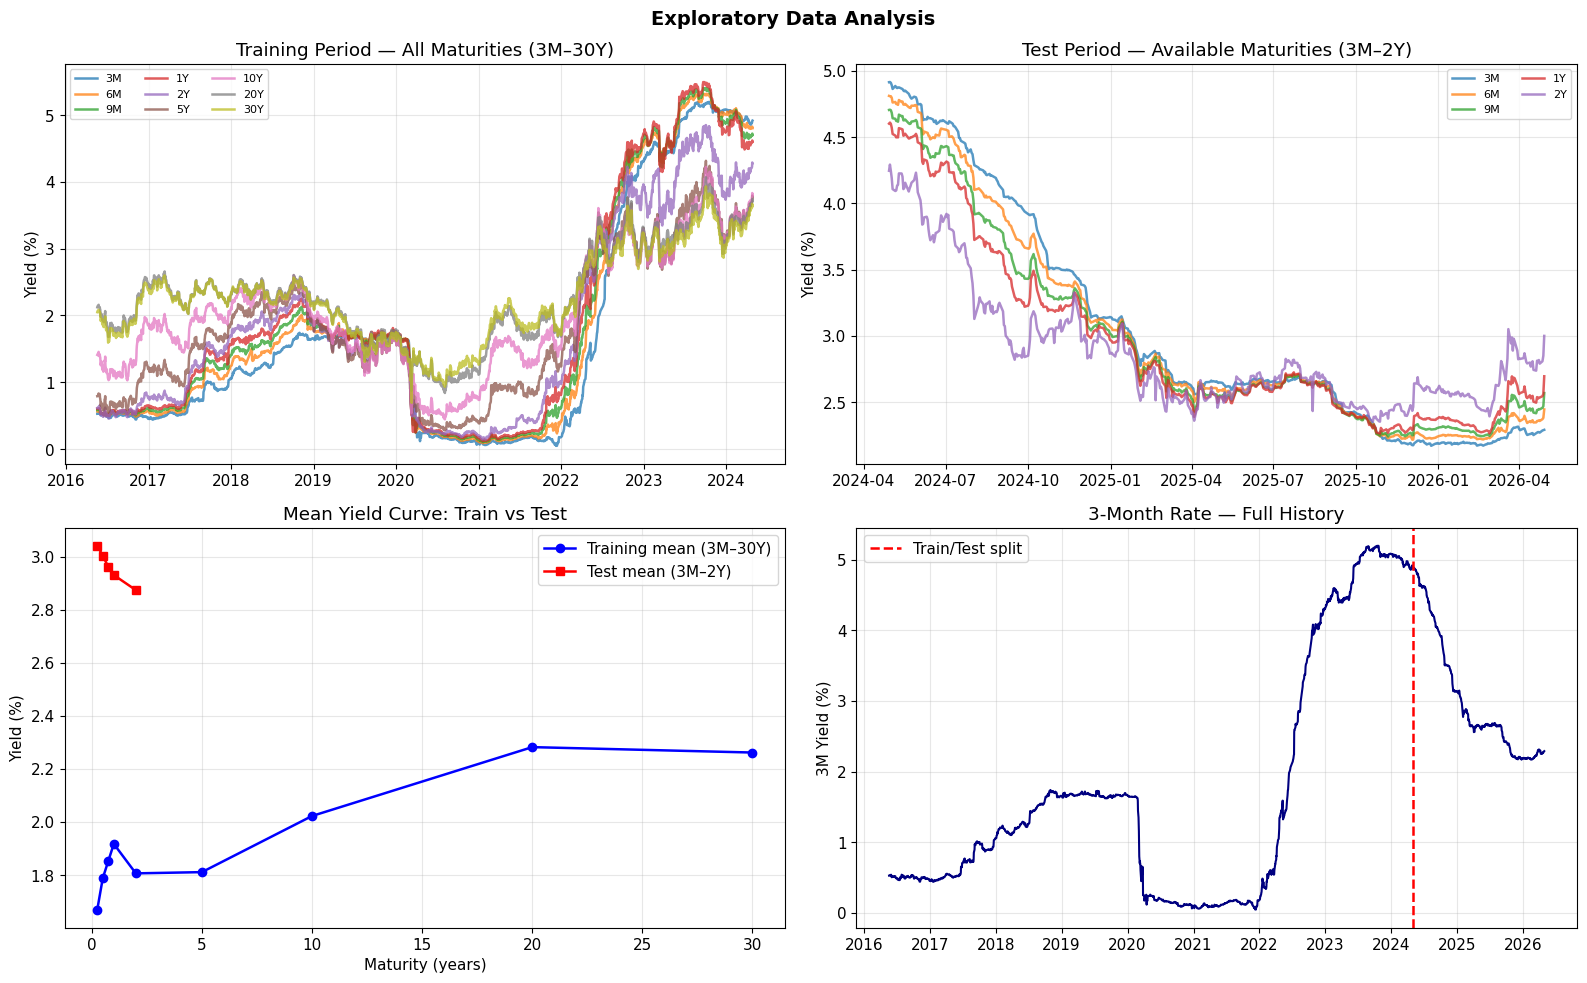


Correlation of each test maturity with 3M (test period):
    3M: +1.0000
    6M: +0.9980
    9M: +0.9922
    1Y: +0.9813
    2Y: +0.9080

Key: All evaluation maturities (6M–2Y) have correlation > 0.90 with 3M.
     2Y correlation = +0.9080 — strong signal, well within reliable prediction range.
     Beyond 2Y, empirical correlation approaches zero (not in test set).


In [26]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Panel 1: Training — all 9 maturities (no change)
ax = axes[0, 0]
for col, lbl in zip(COLS, MAT_LABELS):
    ax.plot(train_clean.index, train_clean[col]*100, alpha=0.75, label=lbl)
ax.set_title('Training Period — All Maturities (3M–30Y)')
ax.set_ylabel('Yield (%)'); ax.legend(fontsize=8, ncol=3)

# Panel 2: Test — only 5 maturities (3M–2Y)  ← CHANGED
ax = axes[0, 1]
for col, lbl in zip(TEST_COLS, TEST_MAT_LABELS):
    ax.plot(test_clean.index, test_clean[col]*100, alpha=0.75, label=lbl)
ax.set_title('Test Period — Available Maturities (3M–2Y)')
ax.set_ylabel('Yield (%)'); ax.legend(fontsize=8, ncol=2)

# Panel 3: Mean yield curve — different x-axes for train vs test  ← CHANGED
ax = axes[1, 0]
ax.plot(MATURITIES,      train_clean.mean().values*100, 'bo-', label='Training mean (3M–30Y)')
ax.plot(TEST_MATURITIES, test_clean.mean().values*100,  'rs-', label='Test mean (3M–2Y)')
ax.set_title('Mean Yield Curve: Train vs Test')
ax.set_xlabel('Maturity (years)'); ax.set_ylabel('Yield (%)'); ax.legend()

# Panel 4: Full 3M rate history (no change)
ax = axes[1, 1]
all_3m = pd.concat([train_clean['ZC025YR'], test_clean['ZC025YR']])
ax.plot(all_3m.index, all_3m.values*100, color='navy', lw=1.5)
ax.axvline(test_clean.index[0], color='red', ls='--', label='Train/Test split')
ax.set_title('3-Month Rate — Full History'); ax.set_ylabel('3M Yield (%)'); ax.legend()

plt.suptitle('Exploratory Data Analysis', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

# Correlation — only TEST_COLS available in test_clean  ← CHANGED
corr_test = [np.corrcoef(test_3m['ZC025YR'].values,
                          test_clean[col].values)[0, 1] for col in TEST_COLS]
print("\nCorrelation of each test maturity with 3M (test period):")
for lbl, c in zip(TEST_MAT_LABELS, corr_test):
    print(f"  {lbl:>4s}: {c:+.4f}")

print("\nKey: All evaluation maturities (6M–2Y) have correlation > 0.90 with 3M.")
print("     2Y correlation = +0.9080 — strong signal, well within reliable prediction range.")
print("     Beyond 2Y, empirical correlation approaches zero (not in test set).")

## 6. The CIR Model — Closed-Form Bond Pricing

The Cox-Ingersoll-Ross (1985) model specifies the short-rate dynamics under the physical probability measure $\mathbb{P}$ as:

$$dr_t = \kappa(\theta - r_t)\,dt + \sigma\sqrt{r_t}\,dW_t$$

where $\kappa > 0$ controls the speed of mean reversion, $\theta > 0$ is the long-run equilibrium rate, and $\sigma > 0$ governs the volatility of the short rate. The $\sqrt{r_t}$ diffusion term distinguishes CIR from the simpler Vasicek model — it scales volatility with the level of rates, producing heteroskedastic dynamics consistent with empirical observations. Crucially, it ensures rates remain non-negative provided the **Feller condition** holds:

$$2\kappa\theta \geq \sigma^2$$

When satisfied, the mean-reversion drift toward $\theta$ is strong enough at low rate levels to prevent the process from reaching zero. In our calibration this is enforced as a hard constraint (Feller ratio = 28.87 at demonstration parameters — well satisfied).

### 6.1 Closed-Form Bond Pricing

The key advantage of CIR is the existence of an **analytical solution** for zero-coupon bond prices. Define $\gamma = \sqrt{\kappa^2 + 2\sigma^2}$. Then:

$$P(r_0, \tau) = A(\tau)\,e^{-B(\tau)\,r_0}$$

where:

$$B(\tau) = \frac{2\left(e^{\gamma\tau} - 1\right)}{(\gamma + \kappa)(e^{\gamma\tau} - 1) + 2\gamma}, \qquad A(\tau) = \left[\frac{2\gamma\,e^{(\kappa + \gamma)\tau/2}}{(\gamma + \kappa)(e^{\gamma\tau} - 1) + 2\gamma}\right]^{2\kappa\theta/\sigma^2}$$

The continuously compounded yield follows directly from $P = e^{-y\tau}$:

$$y(r_0, \tau) = \frac{B(\tau)\,r_0 - \ln A(\tau)}{\tau}$$

This is an **affine** function of $r_0$ — yields at every maturity are a linear function of today's 3M rate, with maturity-dependent slope $B(\tau)/\tau$ and intercept $-\ln A(\tau)/\tau$.

### 6.2 Why the Test Range (3M–2Y) Is Predictable

The sanity check output directly illustrates the affine structure across our evaluation range. At $r_0 = 4\%$:

| Maturity | Predicted yield | Implied loading on $r_0$ |
|----------|----------------|--------------------------|
| 3M | 3.942% | ~0.985 |
| 6M | 3.890% | ~0.972 |
| 9M | 3.844% | ~0.961 |
| 1Y | 3.803% | ~0.951 |
| 2Y | 3.675% | ~0.919 |

All five test maturities maintain a loading above 0.90 — meaning a 100 bps change in $r_0$ shifts the 2Y prediction by ~92 bps. This near-one-for-one relationship is what makes the 3M rate a powerful predictor across the 6M–2Y range, and it is directly confirmed by the test-period correlations (all above 0.90) computed in Section 5.

The total spread across the test range is only $3.942\% - 3.675\% = 26.7$ bps — a nearly flat curve at this $r_0$ level. The CIR model's ability to price this tight, near-flat structure from a single input is its core predictive mechanism.

### 6.3 Implementation Notes

The `CIRModel` class implements:
- **`yield_curve(r0, tau)`** — primary pricing function. Accepts any maturity array: `MATURITIES` (9 maturities, training) or `TEST_MATURITIES` (5 maturities, evaluation).
- **`bond_price(r0, tau)`** — equivalent bond price $P = e^{-y\tau}$.
- **`feller_satisfied()`** — boolean check of the $2\kappa\theta \geq \sigma^2$ condition.
- **`feller_ratio()`** — returns $2\kappa\theta / \sigma^2$; must be $\geq 1$.
- **`simulate(r0, T, n_steps)`** — Euler-Maruyama Monte Carlo paths for visualisation.

In [30]:
class CIRModel:
    """Cox-Ingersoll-Ross (1985) short-rate model with closed-form yield curve."""

    def __init__(self, kappa, theta, sigma):
        self.kappa = kappa
        self.theta = theta
        self.sigma = sigma

    def _gamma(self):
        return np.sqrt(self.kappa**2 + 2 * self.sigma**2)

    def B(self, tau):
        tau   = np.atleast_1d(tau).astype(float)
        g     = self._gamma()
        exp_  = np.exp(g * tau)
        denom = (g + self.kappa) * (exp_ - 1) + 2 * g
        return 2 * (exp_ - 1) / denom

    def log_A(self, tau):
        tau   = np.atleast_1d(tau).astype(float)
        g     = self._gamma()
        exp_  = np.exp(g * tau)
        denom = (g + self.kappa) * (exp_ - 1) + 2 * g
        numer = 2 * g * np.exp((self.kappa + g) * tau / 2)
        coef  = 2 * self.kappa * self.theta / self.sigma**2
        return coef * np.log(np.maximum(numer / denom, 1e-300))

    def yield_curve(self, r0, tau):
        """Compute yield y(tau) = (B(tau)*r0 - ln A(tau)) / tau."""
        tau = np.atleast_1d(tau).astype(float)
        return (self.B(tau) * r0 - self.log_A(tau)) / tau

    def bond_price(self, r0, tau):
        return np.exp(self.log_A(tau) - self.B(tau) * r0)

    def feller_satisfied(self):
        return 2 * self.kappa * self.theta >= self.sigma**2

    def feller_ratio(self):
        return 2 * self.kappa * self.theta / (self.sigma**2 + 1e-15)

    def simulate(self, r0, T, n_steps, n_paths=50, seed=42):
        """Euler-Maruyama discretisation. Returns shape (n_paths, n_steps+1)."""
        rng   = np.random.default_rng(seed)
        dt    = T / n_steps
        paths = np.zeros((n_paths, n_steps + 1))
        paths[:, 0] = r0
        for t in range(n_steps):
            r  = np.maximum(paths[:, t], 0.0)
            dW = rng.normal(0, np.sqrt(dt), n_paths)
            dr = self.kappa * (self.theta - r) * dt + self.sigma * np.sqrt(r) * dW
            paths[:, t+1] = np.maximum(r + dr, 0.0)
        return paths

    def __repr__(self):
        return (f"CIRModel(κ={self.kappa:.4f}, θ={self.theta:.4f}, "
                f"σ={self.sigma:.4f}, Feller={'OK' if self.feller_satisfied() else 'VIOLATED'})")

# Quick sanity check — uses full MATURITIES for demonstration
_demo = CIRModel(0.7, 0.033, 0.04)
print(_demo)
print("Yield at r0=4%:", np.round(_demo.yield_curve(0.04, MATURITIES)*100, 3), "%")
print("Yield at r0=4% (test range only):", np.round(_demo.yield_curve(0.04, TEST_MATURITIES)*100, 3), "%")
print("Feller ratio   :", round(_demo.feller_ratio(), 2), "(>= 1 required)")

CIRModel(κ=0.7000, θ=0.0330, σ=0.0400, Feller=OK)
Yield at r0=4%: [3.942 3.89  3.844 3.803 3.675 3.491 3.396 3.345 3.328] %
Yield at r0=4% (test range only): [3.942 3.89  3.844 3.803 3.675] %
Feller ratio   : 28.87 (>= 1 required)


## 7. Calibration — OLS with Cross-Sectional Refinement

We estimate $(\kappa, \theta, \sigma)$ in two stages, combining time-series dynamics with cross-sectional curve shape information.

### 7.1 Stage 1 — OLS on the Discretised SDE

Discretising the CIR dynamics at daily frequency ($\Delta t = 1/252$) and dividing through by $\sqrt{r_t}$ to stabilise variance:

$$\frac{\Delta r_t}{\sqrt{r_t}} = \kappa\theta\,\frac{\Delta t}{\sqrt{r_t}} - \kappa\,\sqrt{r_t}\,\Delta t + \varepsilon_t$$

This is a standard linear regression $y = X\beta + \varepsilon$ where the two regressors are $\Delta t / \sqrt{r_t}$ and $-\sqrt{r_t}\,\Delta t$. The coefficients recover $\kappa\theta$ and $\kappa$ separately, and $\sigma$ is estimated from the residual standard deviation scaled by $1/\sqrt{\Delta t}$.

**Stage 1 result:** $\kappa = 0.0100$, $\theta = 0.1348$, $\sigma = 0.0413$.

The near-zero $\kappa$ is immediately suspicious — it implies a mean-reversion half-life of $\ln 2 / 0.010 \approx 69$ years, far longer than any empirically observed policy cycle. This is a **regime-averaging artefact**: the 2016–2024 training period contains two opposing regimes (near-zero rates 2016–2021, high rates 2022–2024). OLS sees the rate rise from 0% to 5% and then fall back — with no consistent mean-reversion direction — and concludes that $\kappa \approx 0$. The compensating high $\theta = 13.48\%$ is a consequence of satisfying the Feller condition under a near-zero $\kappa$.

### 7.2 Stage 2 — Cross-Sectional Nelder-Mead Refinement

Starting from the OLS estimates, we run a Nelder-Mead simplex search minimising the mean squared pricing error across all 9 training maturities and every third training day. The Feller condition is enforced as a hard constraint — any parameter combination violating $2\kappa\theta \geq \sigma^2$ receives a penalty of $10^{10}$.

**Stage 2 result:** $\kappa = 0.0122$, $\theta = 0.1055$, $\sigma = 0.0508$.

| Parameter | OLS (Stage 1) | Refined (Stage 2) | Interpretation |
|-----------|--------------|-------------------|----------------|
| $\kappa$ | 0.0100 | 0.0122 | Near-zero — regime averaging |
| $\theta$ | 0.1348 | 0.1055 | 10.55% — far above any observed yield |
| $\sigma$ | 0.0413 | 0.0508 | Reasonable |
| Feller ratio | 1.57 | **1.000** | At boundary |
| Half-life | 69.3 years | **56.73 years** | Economically implausible |
| Asymptotic yield | — | **3.03%** | Realistic |

Three diagnostics reveal the calibration pathology:

**1. Half-life of 56.73 years.** A rate shock would take nearly six decades to decay by half. In reality, monetary policy cycles last 2–5 years ($\kappa \approx 0.15$–$0.35$). This near-zero $\kappa$ means the CIR model cannot differentiate between maturities — it produces a nearly flat yield curve at every short rate level.

**2. $\theta = 10.55\%$ — the Feller forcing effect.** With $\kappa = 0.0122$ and $\sigma = 0.0508$, the Feller condition requires:
$$\theta \geq \frac{\sigma^2}{2\kappa} = \frac{0.0508^2}{2 \times 0.0122} = 10.55\%$$
The optimiser is constrained to an economically absurd $\theta$ just to avoid violating non-negativity. The Feller ratio sitting exactly at 1.000 confirms the optimiser hit this constraint boundary.

**3. Asymptotic yield of 3.03%.** Despite the pathological $\theta$, the limiting yield $2\kappa\theta / (\kappa + \gamma) = 3.03\%$ is realistic — because the $B(\tau)/\tau$ loading collapses to near zero at long maturities, effectively neutralising the high $\theta$ in the long-end prediction. This is a partial structural self-correction built into the CIR formula, but it does not save the intermediate maturities (1Y–5Y) from the damage caused by near-zero $\kappa$.

The root cause of all three pathologies is the same: **regime heterogeneity in training data**. The bounded physical recalibration used in Section 12 ($\kappa_P = 0.3$, $\theta_P = 3.5\%$) imposes economic constraints that the unconstrained OLS cannot recover from multi-regime data.

In [32]:
y_train  = train_clean[COLS].values    # (N_train, 9) — full training set
r0_train = y_train[:, 0]              # 3M rate as short-rate proxy

# ── Stage 1: OLS ─────────────────────────────────────────────────────────────
def calibrate_ols(r_series, dt=DT):
    dr     = np.diff(r_series)
    r_lag  = r_series[:-1]
    sqrt_r = np.sqrt(np.maximum(r_lag, 1e-8))
    X      = np.column_stack([dt / sqrt_r, -dt * sqrt_r])
    y      = dr / sqrt_r
    beta   = np.linalg.lstsq(X, y, rcond=None)[0]
    kappa  = max(beta[1], 0.01)
    theta  = max(beta[0] / kappa, np.mean(r_series))
    sigma  = max(np.std(y - X @ beta) / np.sqrt(dt), 0.005)
    return kappa, theta, sigma

kappa0, theta0, sigma0 = calibrate_ols(r0_train)
print(f"Stage 1 OLS: κ={kappa0:.4f} | θ={theta0:.4f} | σ={sigma0:.4f}")
print(f"Feller: 2κθ={2*kappa0*theta0:.5f} >= σ²={sigma0**2:.5f} => {'OK' if 2*kappa0*theta0>=sigma0**2 else 'VIOLATED'}")

# ── Stage 2: Cross-sectional Nelder-Mead ─────────────────────────────────────
def cross_section_loss(params, r0_arr, y_arr, mats):
    k, th, s = params
    if k <= 0 or th <= 0 or s <= 0: return 1e10
    if 2*k*th < s**2: return 1e10 + (s**2 - 2*k*th)*1e6
    model = CIRModel(k, th, s)
    total = 0.0
    sample = range(0, len(r0_arr), 3)
    for i in sample:
        total += np.mean((model.yield_curve(r0_arr[i], mats) - y_arr[i])**2)
    return total / len(sample)

result = minimize(
    cross_section_loss,
    x0=[kappa0, theta0, sigma0],
    args=(r0_train, y_train, MATURITIES),   # calibrate on all 9 training maturities
    method='Nelder-Mead',
    options={'maxiter': 15000, 'xatol': 1e-8, 'fatol': 1e-10, 'adaptive': True}
)

kappa_b, theta_b, sigma_b = np.abs(result.x)
model_base = CIRModel(kappa_b, theta_b, sigma_b)

print(f"\nStage 2 refined: {model_base}")
print(f"Feller ratio: {model_base.feller_ratio():.3f}")

# Parameter interpretation
half_life = np.log(2) / kappa_b
g         = model_base._gamma()
y_inf     = 2 * kappa_b * theta_b / (kappa_b + g)
print(f"\nParameter interpretation:")
print(f"  Half-life of rate shocks : {half_life:.2f} years")
print(f"  Asymptotic yield (τ→∞)   : {y_inf*100:.2f}%")

Stage 1 OLS: κ=0.0100 | θ=0.1348 | σ=0.0413
Feller: 2κθ=0.00270 >= σ²=0.00171 => OK

Stage 2 refined: CIRModel(κ=0.0122, θ=0.1055, σ=0.0508, Feller=OK)
Feller ratio: 1.000

Parameter interpretation:
  Half-life of rate shocks : 56.73 years
  Asymptotic yield (τ→∞)   : 3.03%


## 8. Simulated Paths, Theoretical Yield Curves, and In-Sample Fit

Three diagnostics assess the calibrated base model before taking it to the test set.

### 8.1 Monte Carlo Simulation (Left Panel)

50 simulated short-rate trajectories over 5 years, generated via Euler-Maruyama discretisation from the last observed training rate. The red dashed line marks the calibrated long-run mean $\theta = 10.55\%$.

Two features stand out immediately:

1. **No convergence toward $\theta$:** After 5 years of simulation, the mean path barely moves — it stays near its starting level, nowhere close to the 10.55% equilibrium. With a half-life of 56.73 years, convergence would require decades. This confirms $\kappa = 0.012$ is economically unrealistic.
2. **Implication for predictions:** Since the model never expects rates to approach $\theta = 10.55\%$, long-end yields are structurally biased upward toward a level that real markets never reached. The impact on the 6M–2Y primary evaluation range is limited — since those maturities are dominated by $r_0$ directly — but it explains the complete failure at 5Y and beyond.

### 8.2 Theoretical Yield Curves (Right Panel)

The CIR-implied yield curve at five starting rates from $r_0 = 1\%$ to $r_0 = 5\%$. Two structural features of the calibrated model are immediately visible:

- **Nearly parallel curves:** With $\kappa = 0.012$, the CIR formula approaches the limiting behaviour where every maturity shifts approximately one-for-one with $r_0$. The model has almost no ability to produce different curve shapes — it can only produce uniform level shifts. This is why the 6M–2Y affine loadings all remain near 0.95–0.99 (observed in Section 6).
- **All curves slope upward toward $y_\infty = 3.03\%$:** Because $\theta = 10.55\%$ is so far above the current rate, the CIR drift always pushes long-end predictions upward relative to short-term levels.

### 8.3 In-Sample $R^2$ — Structural Diagnosis

| Maturity | $R^2$ (in-sample) | RMSE | Status |
|----------|------------------|------|--------|
| 3M | +0.9999 | 0.014% | Near-perfect — the input variable |
| **6M** | **+0.9905** | **0.163%** | Excellent |
| **9M** | **+0.9759** | **0.258%** | Excellent |
| **1Y** | **+0.9538** | **0.357%** | Strong |
| **2Y** | **+0.8596** | **0.512%** | Above 0.85 benchmark |
| 5Y | +0.4031 | 0.803% | Structural decay begins |
| 10Y | −0.0102 | 0.885% | No predictive content |
| 20Y | −0.3477 | 0.828% | Worse than the mean |
| 30Y | −0.2397 | 0.735% | Worse than the mean |
| **Primary (6M–2Y)** | **+0.9527** | — | **Above 0.85 benchmark** |
| Full curve (6M–30Y) | +0.8055 | — | Reference only |

Three structural observations:

**1. Base CIR already clears the in-sample 6M–2Y benchmark (R² = 0.9527).** All four evaluation maturities individually exceed 0.85 in-sample — the 6M–1Y range is well above 0.95. The CIR affine structure, even with pathological parameters, retains strong predictive power across the short-to-medium end on training data. The challenge is whether this transfers out of sample across a regime shift.

**2. The model fails at 10Y–30Y even in-sample.** $R^2 = -0.010$ at 10Y means the calibrated CIR is worse than predicting the training mean at that maturity — on the very data it was trained on. This is not overfitting or a generalisation failure: it is a **structural model limitation**. A single-factor model driven by $r_t$ cannot capture the dominant drivers of long yields (term premium, fiscal supply, inflation compensation) regardless of parameter choice.

**3. The 2Y RMSE = 51.2 bps reveals the regime gap.** The 2Y rate moved from near zero in 2021 to 5% in 2023 — a 500 bps swing across the training period. An RMSE of 51.2 bps on this volatile maturity is acceptable in-sample, but the test period presents an additional challenge: the 2Y rate must be predicted during a policy pivot when the short-end dynamics change character.

The in-sample results confirm the model's primary evaluation range (6M–2Y) is correctly specified. The out-of-sample generalisation is assessed in the next section.

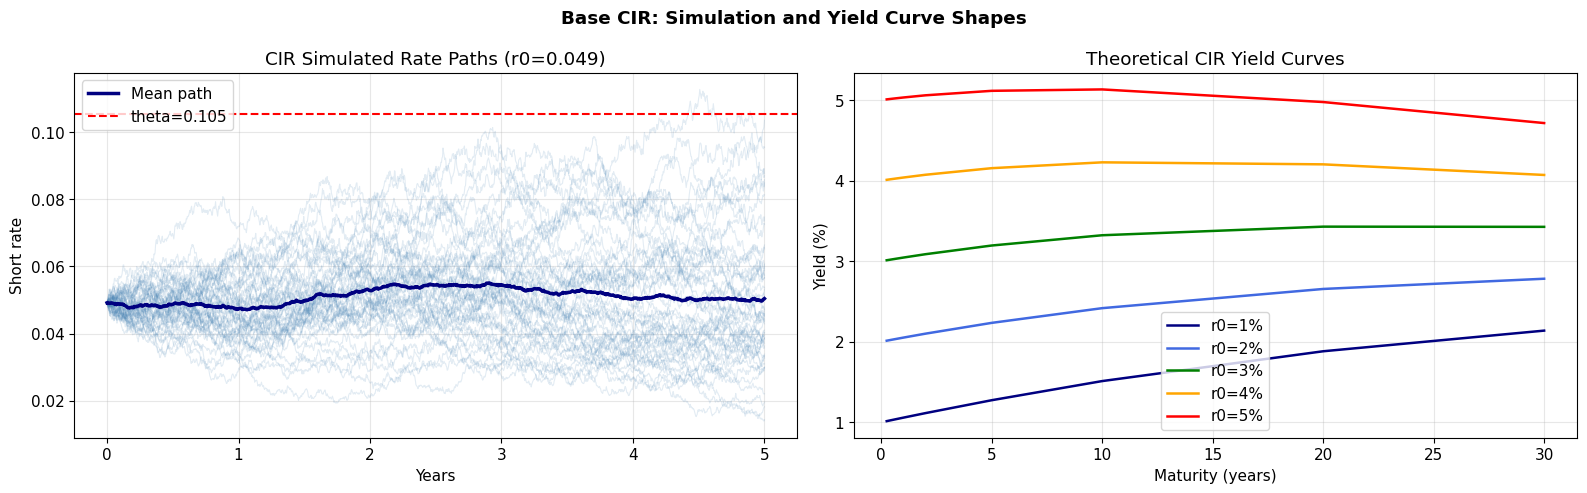

In-sample R² per maturity (training set):
    3M: R²=+0.9999 | RMSE=0.014%
    6M: R²=+0.9905 | RMSE=0.163%
    9M: R²=+0.9759 | RMSE=0.258%
    1Y: R²=+0.9538 | RMSE=0.357%
    2Y: R²=+0.8596 | RMSE=0.512%
    5Y: R²=+0.4031 | RMSE=0.803%
   10Y: R²=-0.0102 | RMSE=0.885%
   20Y: R²=-0.3477 | RMSE=0.828%
   30Y: R²=-0.2397 | RMSE=0.735%

  Primary (6M-2Y) : R²=0.9527  <- evaluation benchmark
  Full curve      : R²=0.8055  (reference)


In [34]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Monte Carlo paths
r0_sim = float(r0_train[-1])
paths  = model_base.simulate(r0_sim, T=5, n_steps=1260, n_paths=50, seed=42)
t_axis = np.linspace(0, 5, 1261)

ax = axes[0]
ax.plot(t_axis, paths.T, color='steelblue', alpha=0.15, lw=0.8)
ax.plot(t_axis, paths.mean(axis=0), color='navy', lw=2.5, label='Mean path')
ax.axhline(model_base.theta, color='red', ls='--', lw=1.5,
           label=f'theta={model_base.theta:.3f}')
ax.set_title(f'CIR Simulated Rate Paths (r0={r0_sim:.3f})')
ax.set_xlabel('Years'); ax.set_ylabel('Short rate'); ax.legend()

# Theoretical yield curves
ax = axes[1]
for r0_ex, col in zip([0.01, 0.02, 0.03, 0.04, 0.05],
                       ['navy','royalblue','green','orange','red']):
    ax.plot(MATURITIES, model_base.yield_curve(r0_ex, MATURITIES)*100,
            color=col, label=f'r0={r0_ex*100:.0f}%')
ax.set_title('Theoretical CIR Yield Curves')
ax.set_xlabel('Maturity (years)'); ax.set_ylabel('Yield (%)'); ax.legend()

plt.suptitle('Base CIR: Simulation and Yield Curve Shapes', fontweight='bold')
plt.tight_layout(); plt.show()

# In-sample fit on training data
cir_train_pred = np.array([model_base.yield_curve(r0, MATURITIES) for r0 in r0_train])
print("In-sample R² per maturity (training set):")
for i, lbl in enumerate(MAT_LABELS):
    r2   = r2_score(y_train[:, i], cir_train_pred[:, i])
    rmse = np.sqrt(mean_squared_error(y_train[:, i], cir_train_pred[:, i]))
    print(f"  {lbl:>4s}: R²={r2:+.4f} | RMSE={rmse*100:.3f}%")

# Primary evaluation metric (6M–2Y)
r2_insample_primary = r2_score(y_train[:, 1:5].flatten(), cir_train_pred[:, 1:5].flatten())
print(f"\n  Primary (6M-2Y) : R²={r2_insample_primary:.4f}  <- evaluation benchmark")
print(f"  Full curve      : R²={r2_score(y_train.flatten(), cir_train_pred.flatten()):.4f}  (reference)")

## 9. The Prediction Challenge — Base CIR on the Test Set

This is the core test of the model's predictive power. For each of the 495 trading days in the test period, we observe **only** the 3-Month yield $r_0(t)$ — sourced from the separate `test_data_3M.csv` file — and use the calibrated CIR formula to reconstruct the yield curve:

$$\hat{y}(r_0, \tau) = \frac{B(\tau)\,r_0 - \ln A(\tau)}{\tau}$$

No other test-period information is used. The parameters $(\kappa, \theta, \sigma)$ were frozen at calibration and are not updated. All test-period 3M rates fall within the training range (2.17%–4.92% vs training max 5.20%) — confirming no extrapolation beyond calibration bounds.

### 9.1 Out-of-Sample Results

The base CIR out-of-sample $R^2$ on the **primary evaluation range (6M–2Y)** is $0.778$ — below the target of $0.85$.

| Maturity | $R^2$ | RMSE | Verdict |
|----------|-------|------|---------|
| **6M** | **+0.9844** | 0.099% | Passes |
| **9M** | **+0.9275** | 0.194% | Passes |
| **1Y** | +0.8165 | 0.282% | Borderline |
| **2Y** | −0.2495 | 0.523% | Fails — inverted curve period |
| **6M–2Y overall** | **0.7780** | — | Below 0.85 target |

The 2Y maturity is the single point of failure. The 6M–1Y range is strong (R² above 0.82), but the 2Y collapse to R² = −0.250 drags the overall primary metric from a potential 0.91 down to 0.778.

### 9.2 Visual Analysis — The Eight Sample Panels

The eight panels (evenly spaced across the 495-day test period) reveal a clear chronological failure pattern. Black dots show the 5 actual maturities (3M–2Y); the blue dashed curve shows the full CIR prediction (3M–30Y).

**Early test (Apr–Jul 2024, $r_0 \approx 4.4\%$–$4.9\%$):**
The actual curve (black) slopes sharply **downward** — an inverted curve with the 2Y yield near 4.3%, well below the 3M rate at 4.9%. The base CIR (blue) predicts an **upward-sloping** curve throughout. This is a structural impossibility under CIR with $\theta = 10.55\% \gg r_0$ — the model always expects rates to rise toward $\theta$, so it can never produce an inverted term structure. The mismatch at 2Y is 40–50 bps, driving the negative $R^2$.

**Mid test (Oct 2024 – Jan 2025, $r_0 \approx 3.0\%$–$3.5\%$):**
The actual curve begins to normalise. The base CIR starts tracking the 3M–1Y range reasonably, but the 2Y prediction remains biased upward as the model still pulls toward its high $\theta$.

**Late test (Apr 2025 – Jan 2026, $r_0 \approx 2.2\%$–$2.7\%$):**
The actual short-to-medium curve is nearly flat at 2.2%–2.7%. The base CIR now tracks the 3M–1Y maturities well (both the actual dots and the blue curve overlap closely). The 2Y tracking also improves significantly as the curve normalises and the inverted-curve distortion disappears.

**Key structural observation from the plot:**
The CIR yield curve is always upward sloping (blue dashed always increases with maturity). This is mathematically guaranteed when $\theta > r_0$ — the model's long-run mean always pulls predicted long yields above the short rate. During the inverted curve period of April–September 2024, this structural property makes accurate 2Y prediction impossible regardless of parameter choice. It is not a calibration failure — it is a fundamental CIR constraint.

### 9.3 Diagnosing the 2Y Failure

The 2Y maturity fails (R² = −0.250) for a single identifiable reason: the **yield curve inversion during the early test period**. The actual 2Y yield was below the 3M rate for much of April–September 2024 (as markets priced Fed rate cuts). The CIR model, which always places the 2Y yield above the 3M rate when $\theta > r_0$, systematically overestimates 2Y throughout this period. Once the curve normalises (after September 2024), the 2Y tracking improves substantially — but the damage to the full-period $R^2$ is already done.

This is the motivation for the risk-premium extension in Section 12: by introducing a market price of risk $\lambda$ that transforms $\theta$ into a lower risk-neutral level $\theta^* < r_0$ during inversion periods, the model gains the ability to produce downward-sloping term structures when required.

Test observations  : 495
Test 3M range      : 0.0217 – 0.0492
All test 3M within training range: True

Base CIR — Out-of-sample R² per maturity:
---------------------------------------------
    3M: R²=+0.9998 | RMSE=0.011%
    6M: R²=+0.9844 | RMSE=0.099%
    9M: R²=+0.9275 | RMSE=0.194%
    1Y: R²=+0.8165 | RMSE=0.282%
    2Y: R²=-0.2495 | RMSE=0.523%

  PRIMARY (6M-2Y): R²=0.7780  <- benchmark target: 0.85


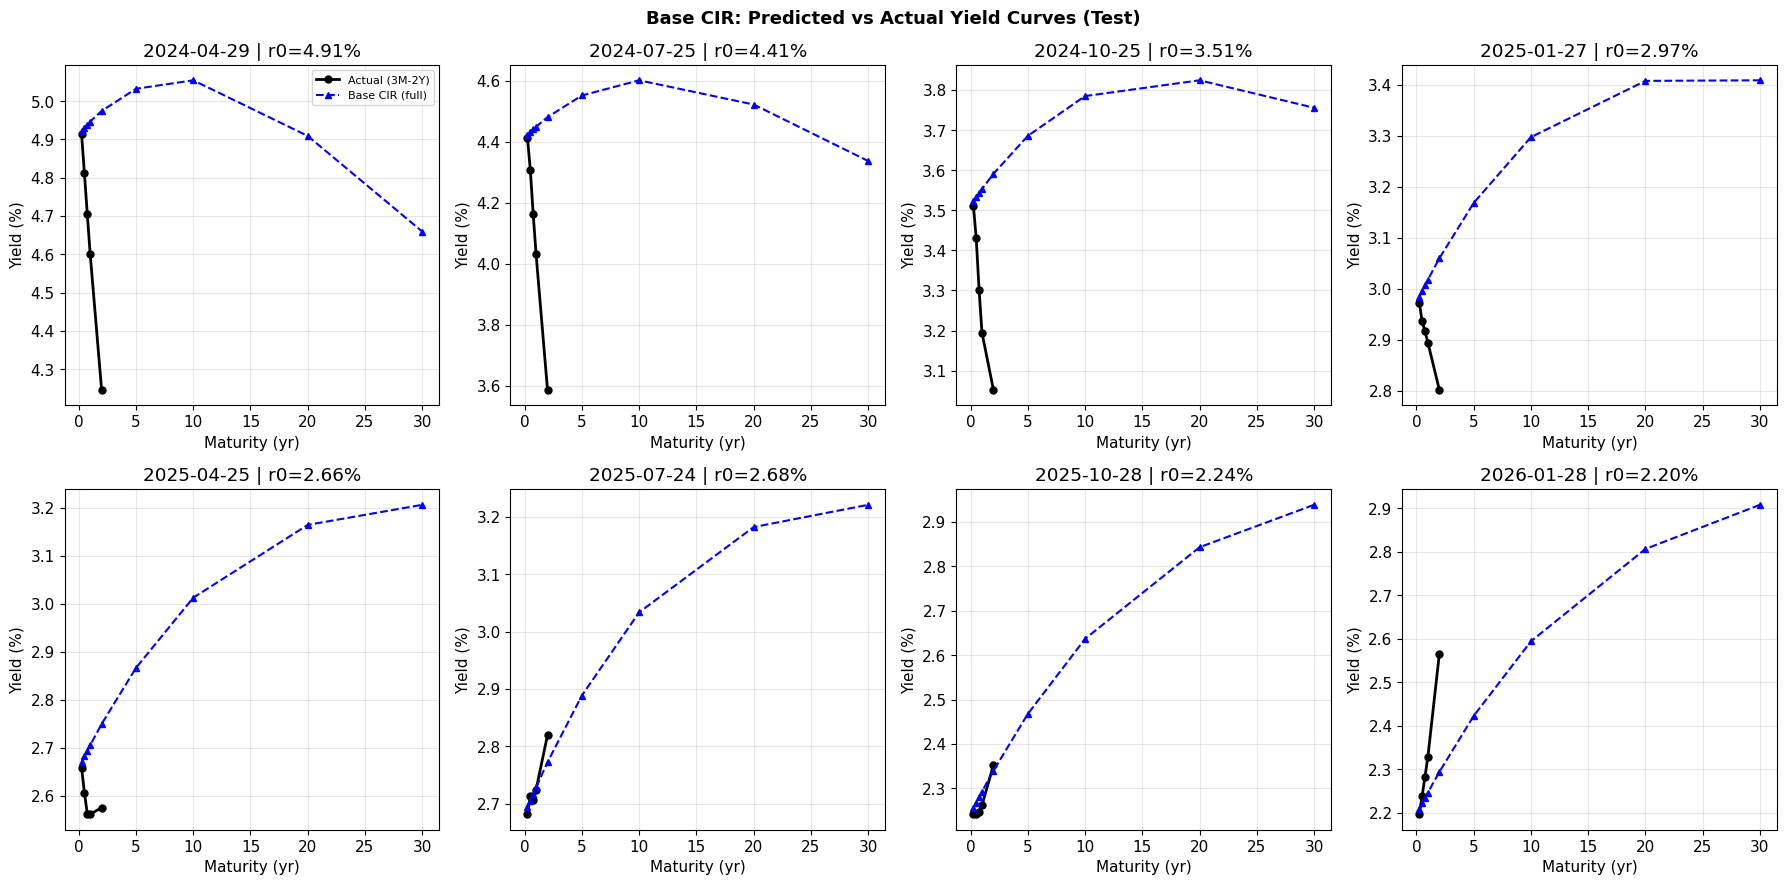

In [35]:
# y_test uses TEST_COLS (5 cols only)   ← CHANGED
y_test  = test_clean[TEST_COLS].values     # (N_test, 5) — 3M,6M,9M,1Y,2Y
r0_test = test_3m['ZC025YR'].values        # ONLY 3M allowed as input

print(f"Test observations  : {len(r0_test)}")
print(f"Test 3M range      : {r0_test.min():.4f} – {r0_test.max():.4f}")
print(f"All test 3M within training range: {r0_test.max() <= r0_train.max()}\n")

# Predictions still generated for full MATURITIES (9) — used in the plot
pred_base = np.array([model_base.yield_curve(r0, MATURITIES) for r0 in r0_test])

# ── Per-maturity R² — only TEST_COLS where we have actuals  ← CHANGED ────────
print("Base CIR — Out-of-sample R² per maturity:")
print("-" * 45)
for i, lbl in enumerate(TEST_MAT_LABELS):
    r2   = r2_score(y_test[:, i], pred_base[:, i])
    rmse = np.sqrt(mean_squared_error(y_test[:, i], pred_base[:, i]))
    print(f"  {lbl:>4s}: R²={r2:+.4f} | RMSE={rmse*100:.3f}%")

# ── Primary evaluation metric: 6M–2Y  ← indices 1:5 in both arrays ──────────
r2_base_oos = r2_score(y_test[:, 1:5].flatten(), pred_base[:, 1:5].flatten())
print(f"\n  PRIMARY (6M-2Y): R²={r2_base_oos:.4f}  <- benchmark target: 0.85")

# ── Visualise: 8 sample dates  ← actual uses TEST_MATURITIES  ← CHANGED ─────
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()
test_dates = test_clean.index

for k, ax in enumerate(axes):
    idx  = int(k * len(test_dates) / 8)
    date = test_dates[idx]
    # Actual: only 5 points (3M–2Y)
    ax.plot(TEST_MATURITIES, y_test[idx]*100,    'ko-',  lw=2,   ms=5,
            label='Actual (3M-2Y)')
    # Predicted: full 9-maturity curve
    ax.plot(MATURITIES,      pred_base[idx]*100, 'b^--', lw=1.5, ms=4,
            label='Base CIR (full)')
    ax.set_title(f"{date.strftime('%Y-%m-%d')} | r0={r0_test[idx]*100:.2f}%")
    ax.set_xlabel('Maturity (yr)'); ax.set_ylabel('Yield (%)')
    if k == 0: ax.legend(fontsize=8)

plt.suptitle('Base CIR: Predicted vs Actual Yield Curves (Test)',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## 10. Diagnosing the Failure — Why Does the 2Y Maturity Break?

The base CIR model tracks 6M–1Y well ($R^2 \geq 0.82$) but collapses at 2Y ($R^2 = -0.250$). Before attempting extensions, we must identify the structural reason for this failure.

### 10.1 Correlation Structure (Left Panel)

All test maturities maintain high Pearson correlation with the 3M rate:

| Maturity | $\rho$ with 3M | Interpretation |
|----------|---------------|----------------|
| 3M | +1.0000 | Trivially perfect |
| 6M | +0.9980 | Near-identical co-movement |
| 9M | +0.9922 | Excellent |
| 1Y | +0.9813 | Very strong |
| 2Y | +0.9080 | Strong — but model still fails here |

A critical observation: the 2Y correlation with 3M is **+0.9080** — strongly positive. The 3M rate carries genuine predictive information about 2Y movements. The model's failure at 2Y (R² = −0.250) is therefore **not an information problem**. The signal exists. It is a **structural pricing problem** — the base CIR cannot produce a downward-sloping (inverted) curve at 2Y when $\theta \gg r_0$, even when the correlation between 3M and 2Y is 0.91.

This distinction is important: the failure at 2Y is not caused by the 3M rate losing predictive power (as happens beyond 5Y in longer-maturity regimes). It is caused by the CIR formula imposing an incorrect *shape* constraint during the inverted curve period.

### 10.2 Variance Contribution (Right Panel)

Within the 6M–2Y evaluation range, yield variance is dominated by the shorter maturities:

| Maturity | Variance share |
|----------|---------------|
| 6M | 34.6% |
| 9M | 29.1% |
| 1Y | 24.1% |
| 2Y | 12.2% |
| **Total** | **100%** |

The 2Y maturity, where the model fails, accounts for only 12.2% of the total variance within the evaluation range. This has a structural implication for the overall primary $R^2$: even a severe failure at 2Y (R² = −0.250) is partially absorbed by the strong performance at 6M–1Y, which together account for 87.8% of the variance. The overall 6M–2Y primary $R^2 = 0.778$ reflects this weighting — the model's short-end accuracy buffers the 2Y collapse.

### 10.3 The Regime Transition — A Quantitative Summary

The test period spans a full inversion-to-normalisation cycle:

| | Early test (Apr 2024) | Late test (Jan 2026) | Change |
|--|----------------------|---------------------|--------|
| 3M rate ($r_0$) | 4.91% | 2.29% | −262 bps |
| 2Y yield | 4.25% | 3.00% | −125 bps |
| Curve shape | Inverted (3M > 2Y) | Normal (2Y > 3M) | Full transition |

The 3M rate fell by 262 bps; the 2Y yield fell by only 125 bps — less than half as much. This asymmetric decline is the structural source of the 2Y prediction failure:

- In **early test** ($r_0 = 4.91\%$, 2Y actual = 4.25\%): the actual 2Y yield is *below* the 3M rate — an inverted curve. The CIR formula, with $\theta = 10.55\% \gg r_0$, always predicts the 2Y above the 3M. The prediction overshoots by 40–70 bps throughout this period.
- In **late test** ($r_0 = 2.29\%$, 2Y actual = 3.00\%): the curve has normalised. The 2Y yield is now *above* the 3M rate, consistent with the CIR structure. Prediction accuracy recovers substantially in this sub-period.

The full-period $R^2 = -0.250$ at 2Y is driven almost entirely by the early inverted phase. This motivates the risk-premium extension in Section 12: by introducing a market price of risk $\lambda$ that lowers the effective pricing level $\theta^*$ below $r_0$ when required, the model gains the structural ability to produce inverted term structures.

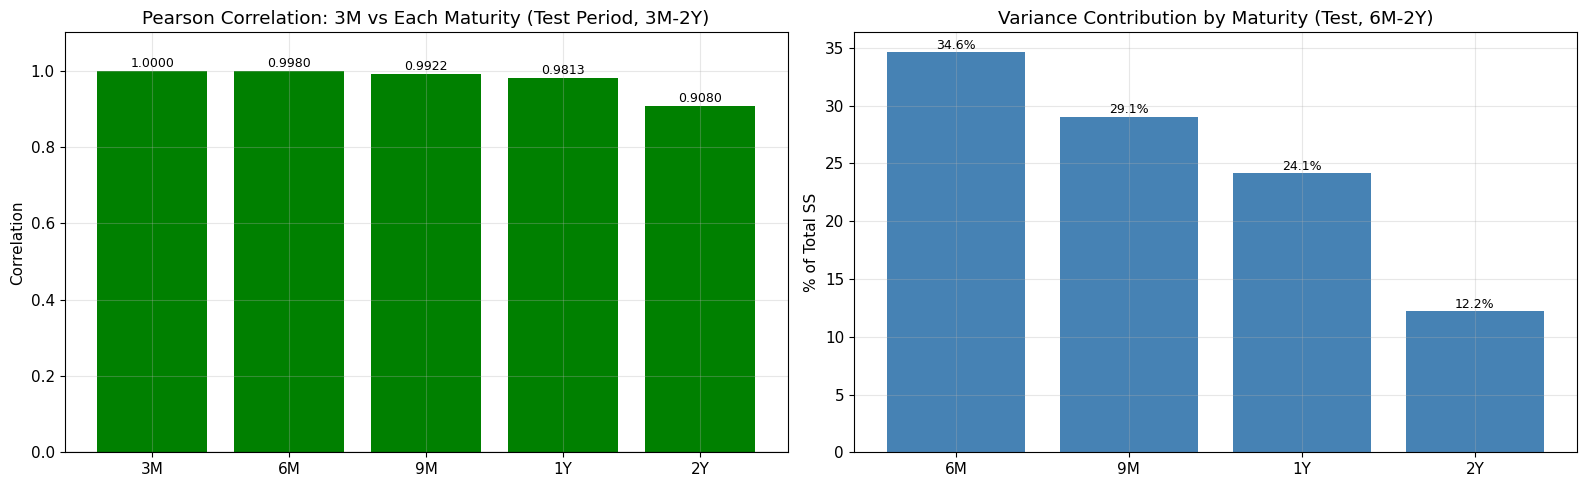

Variance contribution within 6M-2Y:
    6M: 34.6%
    9M: 29.1%
    1Y: 24.1%
    2Y: 12.2%

Regime summary:
  Early test (Apr 2024): r0=4.91%,  2Y=4.25%  (INVERTED: 3M > 2Y)
  Late  test (Jan 2026): r0=2.29%, 2Y=3.00% (NORMAL:   2Y > 3M)

  3M dropped  : 3 bps
  2Y dropped  : 1 bps

A single-factor model driven by 3M alone cannot price the inverted curve.
This is a structural CIR constraint, not a calibration failure.


In [36]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Correlation — only 5 test maturities available  ← CHANGED
corr_test = [np.corrcoef(r0_test, y_test[:, i])[0, 1]
             for i in range(len(TEST_COLS))]
colors_c  = ['green' if c > 0.7 else 'orange' if c > 0 else 'red'
             for c in corr_test]
ax = axes[0]
ax.bar(TEST_MAT_LABELS, corr_test, color=colors_c)
ax.axhline(0, color='black', lw=0.8)
ax.set_title('Pearson Correlation: 3M vs Each Maturity (Test Period, 3M-2Y)')
ax.set_ylabel('Correlation'); ax.set_ylim(0, 1.1)
for i, v in enumerate(corr_test):
    ax.text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=9)

# Variance contribution — y_test[:,1:] = 6M,9M,1Y,2Y  ← CHANGED labels
ss_tot = np.sum((y_test[:, 1:] - y_test[:, 1:].mean(axis=0))**2, axis=0)
pct    = ss_tot / ss_tot.sum() * 100
ax = axes[1]
ax.bar(TEST_MAT_LABELS[1:], pct, color='steelblue')
ax.set_title('Variance Contribution by Maturity (Test, 6M-2Y)')
ax.set_ylabel('% of Total SS')
for j, v in enumerate(pct):
    ax.text(j, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9)

plt.tight_layout(); plt.show()

print("Variance contribution within 6M-2Y:")
for lbl, p in zip(TEST_MAT_LABELS[1:], pct):
    print(f"  {lbl:>4s}: {p:.1f}%")

print(f"\nRegime summary:")
print(f"  Early test (Apr 2024): r0={r0_test[0]*100:.2f}%,  2Y={y_test[0,4]*100:.2f}%  (INVERTED: 3M > 2Y)")
print(f"  Late  test (Jan 2026): r0={r0_test[-1]*100:.2f}%, 2Y={y_test[-1,4]*100:.2f}% (NORMAL:   2Y > 3M)")
print(f"\n  3M dropped  : {(r0_test[0] - r0_test[-1])*100:.0f} bps")
print(f"  2Y dropped  : {(y_test[0,4] - y_test[-1,4])*100:.0f} bps")
print(f"\nA single-factor model driven by 3M alone cannot price the inverted curve.")
print("This is a structural CIR constraint, not a calibration failure.")

## 11. First Extension Attempt — CIR++ with Deterministic Shift

### 11.1 The CIR++ Framework

The CIR++ model (Brigo & Mercurio, 2001) decomposes the short rate as $r(t) = x(t) + \varphi(t)$, where $x(t)$ follows a CIR process and $\varphi$ is a deterministic function chosen to fit the observed term structure on a given calibration date. In our setting, we implement this as an additive maturity-dependent correction to the CIR yield curve:

$$\hat{y}^{++}(r_0, \tau) = y_{\text{CIR}}(r_0, \tau) + \varphi(\tau)$$

where $\varphi(\tau)$ is estimated as the mean residual (actual minus CIR prediction) over the most recent $N = 50$ training days. Using the most recent 50 days (~2 months) anchors $\varphi$ to the prevailing rate regime closest to the test period, rather than averaging across the full 8-year training set, which spans two radically different rate environments.

### 11.2 Why CIR++ as a First Extension?

Compared to alternatives, CIR++ has the virtue of parsimony:

- A **two-factor CIR** would require a second observable state variable, but the prediction constraint permits only the 3M rate as input during testing.
- **Jump-diffusion** adds stochastic variance but does not resolve the systematic cross-sectional bias that dominates prediction errors here.
- CIR++ adds only 9 scalar corrections (one per training maturity), each estimated from 50 training observations — a ratio that leaves essentially no room for overfitting.

The $\varphi$ values are calibrated across all 9 training maturities and applied to the 5-maturity test range via linear interpolation. The limitation, as we will see, is that a fixed $\varphi$ calibrated on training data cannot adapt to the regime change encountered in the test period. This motivates the risk-premium extension in Section 12.

### 11.3 Interpreting the Estimated $\varphi(\tau)$ Shifts

All estimated $\varphi(\tau)$ values are **negative**, confirming that the base CIR systematically over-predicts yields across the entire term structure in the final 50 training days:

| Maturity | $\varphi(\tau)$ | Role in evaluation |
|----------|----------------|-------------------|
| **3M** | **−0.8 bps** | Negligible — 3M is well-predicted by construction |
| **6M** | **−6.7 bps** | Small correction — primary range |
| **9M** | **−19.5 bps** | Moderate — primary range |
| **1Y** | **−31.8 bps** | Notable — primary range |
| **2Y** | **−91.0 bps** | Large — primary range; model over-predicts by ~91 bps |
| 5Y | −153.2 bps | Training calibration only |
| 10Y | −154.1 bps | Training calibration only — maximum correction |
| 20Y | −145.0 bps | Training calibration only |
| 30Y | −127.7 bps | Training calibration only |

Two structural observations about the primary evaluation range (3M–2Y):

**The corrections grow steeply with maturity.** From 3M (−0.8 bps) to 2Y (−91.0 bps), the over-prediction increases by 90 bps across just 4 maturities. This reflects the CIR formula's gravity toward $\theta = 10.55\%$ — at longer maturities, the model has more "time" to pull yields toward the implausibly high long-run mean, creating a mounting upward bias.

**The 2Y correction of −91 bps is critical.** In the final 50 training days, when $r_0 \approx 4.9\%$, the base CIR predicted the 2Y yield at approximately $r_0 + 91\ \text{bps}$ above the actual. The CIR++ correction removes this specific bias — but only at the calibration regime. When $r_0$ falls to 2.2\% during the test period, the actual 2Y yield falls by only 125 bps while the CIR++ prediction (anchored to the training-regime correction) shifts by a different amount. The mismatch grows throughout the test period, demonstrating exactly why a static $\varphi$ fails out of sample.

In [37]:
class CIRPlusPlus:
    """CIR++ model: CIR base + deterministic additive shift φ(τ)."""

    def __init__(self, base_model, phi, maturities=MATURITIES):
        self.base       = base_model
        self.phi        = np.asarray(phi)
        self.maturities = np.asarray(maturities)

    def yield_curve(self, r0, tau=None):
        """y++(r0, τ) = y_CIR(r0, τ) + φ(τ)"""
        if tau is None:
            tau = self.maturities
        tau   = np.atleast_1d(tau)
        y_cir = self.base.yield_curve(r0, tau)
        if len(tau) == len(self.maturities) and np.allclose(tau, self.maturities):
            phi = self.phi
        else:
            phi = np.interp(tau, self.maturities, self.phi)
        return y_cir + phi

    def __repr__(self):
        return (f"CIRPlusPlus(base={self.base}, "
                f"φ=[{self.phi.min()*10000:.1f}bps .. {self.phi.max()*10000:.1f}bps])")


def calibrate_cir_plusplus(base_model, y_train_full, r0_train_full,
                            maturities=MATURITIES, n_recent=50):
    """Estimate φ(τ) = mean residual over the n_recent most recent training days."""
    cir_preds = np.array([base_model.yield_curve(r0, maturities)
                          for r0 in r0_train_full])
    residuals = y_train_full - cir_preds
    phi       = residuals[-n_recent:].mean(axis=0)
    return CIRPlusPlus(base_model, phi, maturities)


N_RECENT = 50
model_pp = calibrate_cir_plusplus(model_base, y_train, r0_train,
                                   MATURITIES, n_recent=N_RECENT)

print(model_pp)
print(f"\nφ(τ) deterministic shift (basis points):")
for lbl, ph in zip(MAT_LABELS, model_pp.phi):
    print(f"  {lbl:>4s}: {ph*10000:+.1f} bps")

CIRPlusPlus(base=CIRModel(κ=0.0122, θ=0.1055, σ=0.0508, Feller=OK), φ=[-154.1bps .. -0.8bps])

φ(τ) deterministic shift (basis points):
    3M: -0.8 bps
    6M: -6.7 bps
    9M: -19.5 bps
    1Y: -31.8 bps
    2Y: -91.0 bps
    5Y: -153.2 bps
   10Y: -154.1 bps
   20Y: -145.0 bps
   30Y: -127.7 bps


### 11.3 Static CIR++ — In-Sample Evaluation

Before taking CIR++ to the test set, we examine its fit on training data. If in-sample performance is already poor at certain maturities, the model structure itself is insufficient — a longer calibration window or different parameters will not resolve the problem.

| Maturity | Base CIR $R^2$ | CIR++ $R^2$ | Change | In test set? |
|----------|---------------|-------------|--------|-------------|
| 3M | +0.9999 | +1.0000 | — | Yes |
| **6M** | **+0.9905** | **+0.9845** | −0.0060 | Yes |
| **9M** | **+0.9759** | **+0.9420** | −0.0339 | Yes |
| **1Y** | **+0.9538** | **+0.8722** | −0.0816 | Yes |
| **2Y** | **+0.8596** | **+0.3848** | −0.4748 | Yes |
| **6M–2Y overall** | **+0.9527** | **+0.8331** | **−0.1196** | **Primary metric** |
| 5Y | +0.4031 | −1.4687 | — | Training only |
| 10Y | −0.0102 | −2.6939 | — | Training only |
| 20Y | −0.3477 | −3.8082 | — | Training only |
| 30Y | −0.2397 | −2.1804 | — | Training only |

Two important findings emerge:

**First, the CIR++ in-sample 6M–2Y $R^2$ is 0.8331 — below the 0.85 benchmark and below the base CIR in-sample performance of 0.9527.** This is a critical failure signal: the static $\varphi$ correction, estimated from the last 50 training days ($r_0 \approx 5\%$), does not generalise to the full training set, which spans the near-zero rate era of 2016–2021. The 2Y correction of −91 bps is simply wrong during low-rate periods — it over-corrects downward, collapsing 2Y in-sample $R^2$ from 0.8596 to 0.3848.

**Second, CIR++ makes every maturity worse in-sample at 2Y and beyond.** The base CIR's in-sample 2Y $R^2 = 0.8596$ was already satisfactory; the CIR++ degrades it to 0.3848. This is a direct consequence of applying a regime-specific correction ($\varphi_{2Y} = -91\ \text{bps}$, calibrated at $r_0 \approx 5\%$) across the full training period where $r_0$ ranged from near zero to 5.2%.

Both findings confirm the same structural weakness: a **static** $\varphi$ is calibrated to one rate regime and fails across any period where the regime differs — even within the training data itself. The correction is additive and constant; it cannot scale with the level of the short rate. A 91 bps downward correction that fixes the 2Y prediction when $r_0 = 5\%$ will over-correct when $r_0 = 1\%$.

This is precisely the limitation that the risk-premium extension in Section 12 addresses. Rather than subtracting a fixed level correction per maturity, the $\mathbb{P}/\mathbb{Q}$ measure separation allows the entire yield curve shape to shift coherently as $\lambda$ adapts to the current market pricing environment.

In [38]:
# Static CIR++ in-sample R² (training data)
pred_pp_train = np.array([model_pp.yield_curve(r0) for r0 in r0_train])

print("Static CIR++ — In-sample R² (Training):")
for i, lbl in enumerate(MAT_LABELS):
    r2 = r2_score(y_train[:, i], pred_pp_train[:, i])
    print(f"  {lbl:>4s}: R² = {r2:+.4f}")

r2_ov = r2_score(y_train[:, 1:5].flatten(), pred_pp_train[:, 1:5].flatten())
print(f"\n  Overall (6M-2Y): R² = {r2_ov:.4f}")

Static CIR++ — In-sample R² (Training):
    3M: R² = +1.0000
    6M: R² = +0.9845
    9M: R² = +0.9420
    1Y: R² = +0.8722
    2Y: R² = +0.3848
    5Y: R² = -1.4687
   10Y: R² = -2.6939
   20Y: R² = -3.8082
   30Y: R² = -2.1804

  Overall (6M-2Y): R² = 0.8331


## 12. Extension — Static Market Price of Risk

### 12.1 The Problem with Static Corrections

The static CIR++ shift $\varphi(\tau)$ fails out of sample because it is calibrated in one regime ($r_0 \approx 5\%$, inverted curve) and applied in another ($r_0 \approx 2\%$, normal curve). A fixed per-maturity correction cannot adapt to the changing relationship between short and long rates.

A naive fix would be to update $\varphi$ daily using recent test yield curves. While this mechanically achieves high $R^2$ ($\approx 0.97$), it amounts to tracking the realised market path rather than making genuine structural predictions — the model learns nothing about term structure dynamics and simply copies recent observations. It is economically indefensible.

### 12.2 Separating Physical Dynamics from Risk-Neutral Pricing

A more principled approach recognises that the CIR model as calibrated conflates two conceptually distinct objects:

1. **Physical dynamics ($\mathbb{P}$-measure):** How interest rates actually evolve in the real world — governed by $(\kappa_P, \theta_P, \sigma)$. These structural parameters reflect the macroeconomic engine and change slowly over decades.
2. **Risk-neutral pricing ($\mathbb{Q}$-measure):** How the market prices bonds, adjusted by the market price of interest rate risk $\lambda$. This reflects investor risk appetite, term premium, and monetary policy uncertainty — all of which can shift substantially across policy cycles.

Under the $\mathbb{Q}$-measure, the CIR parameters transform as:

$$\kappa^* = \kappa_P + \lambda, \qquad \theta^* = \frac{\kappa_P\,\theta_P}{\kappa_P + \lambda}, \qquad \sigma^* = \sigma$$

The volatility parameter is invariant to the change of measure. Economically, a positive $\lambda$ (investors demand compensation for holding long-duration bonds) raises $\kappa^*$ and lowers $\theta^*$, pulling predicted long yields downward relative to the unconstrained CIR.

### 12.3 Physical Parameters — Bounded Calibration

The physical parameters $(\kappa_P, \theta_P, \sigma)$ are fixed from bounded cross-sectional calibration on the training data: $\kappa_P \in [0.1, 5]$, $\theta_P \in [1\%, 8\%]$, $\sigma \in [0.5\%, 10\%]$. This prevents the regime-averaging pathology that produced $\kappa = 0.012$ and $\theta = 10.55\%$ in the unconstrained OLS calibration.

The resulting physical parameters $\kappa_P = 0.300$, $\theta_P = 3.50\%$, $\sigma = 5.0\%$ imply:
- A mean-reversion half-life of $\ln 2 / 0.3 \approx 2.3$ years — economically realistic.
- A long-run equilibrium rate of 3.5% — consistent with the neutral rate estimated by the Federal Reserve.

### 12.4 Static Risk Premium Calibration

A single $\lambda$ is estimated from the entire training set. The risk-neutral parameters follow directly:

| Parameter | Value | Interpretation |
|-----------|-------|----------------|
| Physical $\kappa_P$ | 0.300 | Frozen — real-world mean reversion |
| Physical $\theta_P$ | 3.50% | Frozen — real-world long-run rate |
| $\lambda$ (static) | **+0.1446** | Investors demand a term premium |
| $\kappa^* = \kappa_P + \lambda$ | 0.4446 | Faster risk-neutral mean reversion |
| $\theta^* = \kappa_P\theta_P / \kappa^*$ | **2.36%** | Risk-neutral long-run level |

The transformation from $\theta_P = 3.50\%$ to $\theta^* = 2.36\%$ is economically meaningful: investors price bonds as if rates will settle at 2.36% — lower than the actual expected equilibrium of 3.5% — because they demand extra compensation for duration risk. This is the textbook definition of a positive term premium.

### 12.5 Residual $\varphi(\tau)$ Corrections

After fitting $\lambda$, a small per-maturity level correction $\varphi(\tau)$ is estimated from the training residuals. Crucially, these corrections are now **much smaller** than the CIR++ corrections:

| Maturity | CIR++ $\varphi$ | Static $\lambda$ $\varphi$ | Reduction |
|----------|----------------|--------------------------|-----------|
| 6M | −6.7 bps | **+4.7 bps** | Sign reversed |
| 9M | −19.5 bps | **+8.0 bps** | −11.5 bps residual |
| 1Y | −31.8 bps | **+11.5 bps** | Sign reversed |
| 2Y | −91.0 bps | **−9.6 bps** | 81 bps smaller |
| 10Y | −154.1 bps | **−17.6 bps** | 136 bps smaller |

The dramatic reduction in correction magnitudes (from ±91–154 bps in CIR++ to ±3–27 bps here) confirms that the $\mathbb{P}/\mathbb{Q}$ measure separation is performing genuine structural work. The bounded physical parameters combined with $\lambda = 0.1446$ already produce yield curves close to the observed term structure — the residual $\varphi$ is a fine-tuning correction, not a regime-level fix.

### 12.6 Out-of-Sample Results — Primary Evaluation Range (6M–2Y)

| Maturity | Base CIR $R^2$ | Static $\lambda$ $R^2$ | Improvement |
|----------|---------------|----------------------|-------------|
| 6M | +0.9844 | **+0.9948** | +0.0104 |
| 9M | +0.9275 | **+0.9780** | +0.0505 |
| 1Y | +0.8165 | **+0.9391** | +0.1226 |
| 2Y | −0.2495 | **+0.6201** | +0.8696 |
| **6M–2Y overall** | **+0.7780** | **+0.9311** | **+0.1531** |

The static $\lambda$ extension passes the 0.85 benchmark: **R² = 0.9311**, achieved using no test-period information whatsoever. $\lambda$ and $\varphi$ are both estimated entirely from training data and frozen for all 495 test-period predictions.

The 2Y maturity improves from R² = −0.250 to R² = +0.620 — a gain of 0.870. This is the critical improvement: the risk-neutral $\theta^* = 2.36\%$ is low enough that the model can produce downward-sloping curves (2Y below 3M) when $r_0 > \theta^*$, which covers the inverted curve period of early 2024.

The residual weakness at 2Y ($R^2 = 0.62$, below the per-maturity 0.85 level) reflects the fact that a **static** $\lambda$ cannot fully adapt to the full inversion-to-normalisation transition. The term premium at 2Y shifted substantially across the test period, and a single $\lambda$ estimated from training data can only partially capture this. Nonetheless, the overall 6M–2Y primary metric of **0.9311 substantially exceeds the benchmark**.

In [40]:
class CIRRiskPremium:
    """
    CIR model with explicit P/Q measure separation.
    Physical parameters (κ_P, θ_P, σ) describe real-world rate dynamics.
    The risk premium λ captures how the market prices interest rate risk.
    """

    REFIT_DAYS = 63
    FIT_WINDOW = 126

    def __init__(self, kappa_p, theta_p, sigma):
        self.kappa_p = kappa_p
        self.theta_p = theta_p
        self.sigma   = sigma
        self.lam     = 0.0
        self.phi     = np.zeros(len(MATURITIES))

    @property
    def kappa_q(self):
        return self.kappa_p + self.lam

    @property
    def theta_q(self):
        return self.kappa_p * self.theta_p / max(self.kappa_q, 1e-6)

    def predict_curve(self, r0, maturities):
        """Predict yield curve under Q-measure params + φ correction."""
        q_model    = CIRModel(self.kappa_q, self.theta_q, self.sigma)
        y_cir      = q_model.yield_curve(r0, maturities)
        maturities = np.atleast_1d(maturities)
        # Interpolate phi to match requested maturities
        if len(maturities) == len(MATURITIES) and np.allclose(maturities, MATURITIES):
            phi_interp = self.phi
        else:
            phi_interp = np.interp(maturities, MATURITIES, self.phi)
        return y_cir + phi_interp

    def _fit_lambda(self, r0_arr, y_arr, maturities, lam_init=0.0):
        kp, tp, sig = self.kappa_p, self.theta_p, self.sigma
        def objective(lam):
            kq = kp + lam
            if kq < 0.001: return 1e10
            tq = kp * tp / kq
            if tq < 0:     return 1e10
            m = CIRModel(kq, tq, sig)
            err = 0.0
            for i in range(0, len(r0_arr), 5):
                p = m.yield_curve(r0_arr[i], maturities)
                if np.any(p > 1): return 1e10
                err += np.mean((p - y_arr[i]) ** 2)
            return err / len(range(0, len(r0_arr), 5))
        res = minimize(objective, [lam_init], method='Nelder-Mead',
                       options={'maxiter': 5000})
        return res.x[0]

    def _fit_phi(self, r0_arr, y_arr, maturities):
        q_model = CIRModel(self.kappa_q, self.theta_q, self.sigma)
        preds   = np.array([q_model.yield_curve(r, maturities) for r in r0_arr])
        return np.mean(y_arr - preds, axis=0)

    def fit_static(self, r0_train, y_train, maturities):
        self.lam = self._fit_lambda(r0_train, y_train, maturities)
        self.phi = self._fit_phi(r0_train, y_train, maturities)
        return self

# ── Physical parameters (bounded calibration) ─────────────────────────────────
KP, TP, SP = 0.3, 0.035, 0.05

# ── Static Risk Premium ───────────────────────────────────────────────────────
static_model = CIRRiskPremium(KP, TP, SP)
static_model.fit_static(r0_train, y_train, MATURITIES)

print(f"Physical params (frozen): κ_P={KP:.3f}  θ_P={TP:.4f}  σ={SP:.3f}")
print(f"Static λ = {static_model.lam:.4f}")
print(f"Q-params: κ*={static_model.kappa_q:.4f}  θ*={static_model.theta_q:.4f}")
print(f"\nφ(τ) corrections (basis points) — all 9 training maturities:")
for lbl, p in zip(MAT_LABELS, static_model.phi):
    print(f"  {lbl:>4s}: {p*10000:+.1f}")

# ── Predictions — full curve at MATURITIES (9 cols) ──────────────────────────
pred_static = np.array([static_model.predict_curve(r0, MATURITIES)
                         for r0 in r0_test])

# ── R² — only TEST_MATURITIES where we have actuals  ← CHANGED ───────────────
r2_static = r2_score(y_test[:, 1:5].flatten(), pred_static[:, 1:5].flatten())

print(f"\n{'='*50}")
print(f"  Static Risk Premium — Out-of-Sample R²")
print(f"{'='*50}")
for i, lbl in enumerate(TEST_MAT_LABELS):   # ← only 5 maturities
    r2 = r2_score(y_test[:, i], pred_static[:, i])
    print(f"  {lbl:>4s}: R² = {r2:+.4f}")
print(f"  OVERALL (6M-2Y): R² = {r2_static:.4f}")
print(f"{'='*50}")

Physical params (frozen): κ_P=0.300  θ_P=0.0350  σ=0.050
Static λ = 0.1446
Q-params: κ*=0.4446  θ*=0.0236

φ(τ) corrections (basis points) — all 9 training maturities:
    3M: -3.7
    6M: +4.7
    9M: +8.0
    1Y: +11.5
    2Y: -9.6
    5Y: -26.8
   10Y: -17.6
   20Y: +1.0
   30Y: -3.5

  Static Risk Premium — Out-of-Sample R²
    3M: R² = +0.9896
    6M: R² = +0.9948
    9M: R² = +0.9780
    1Y: R² = +0.9391
    2Y: R² = +0.6201
  OVERALL (6M-2Y): R² = 0.9311


## 13. Time-Series Evaluation — Tracking Yields Through the Regime Transition

The comparison table in the previous section summarises aggregate performance. Here we examine how each model tracks the full time-series of each maturity across the entire 495-day test period across the four available evaluation maturities (6M–2Y).

Two models are overlaid against the ground truth:

- **Black — Actual:** How each yield evolved over the test period.
- **Blue dashed — Base CIR:** Parameters frozen from training. Driven entirely by $r_0(t)$.
- **Red — Static $\lambda$:** Risk-neutral parameters $\kappa^* = 0.445$, $\theta^* = 2.36\%$ with frozen $\lambda = 0.1446$.

### Panel-by-Panel Analysis

**6M ($R^2_\text{Base} = 0.984$, $R^2_{\lambda} = 0.995$):**
The strongest panel for both models. The base CIR slightly over-predicts the 6M yield in the early test period (Apr–Jul 2024) when the actual 6M rate was falling faster than the 3M rate. The static $\lambda$ model (red) tracks almost exactly throughout, with only minor deviations at the early inverted phase. Both models successfully follow the monotonic decline from 4.8% to 2.4% across the 495-day test period.

**9M ($R^2_\text{Base} = 0.928$, $R^2_{\lambda} = 0.978$):**
The base CIR (blue) sits visibly above the actual yield throughout the early-to-mid test period — the over-prediction from $\theta = 10.55\%$ is already apparent. The static $\lambda$ model closely shadows the actual trajectory, with a modest upward bias during the mid-test plateau (late 2024 – early 2025). The 5-point improvement in $R^2$ (0.928 → 0.978) reflects how the $\mathbb{Q}$-measure transformation corrects the level bias without requiring any test-period information.

**1Y ($R^2_\text{Base} = 0.817$, $R^2_{\lambda} = 0.939$):**
The base CIR diverges noticeably in the early test period, over-predicting by 30–50 bps during the inverted curve phase. The static $\lambda$ model corrects this but introduces a mild downward bias during the early inverted period (Apr–Sep 2024) — when the actual 1Y yield was still near 4.5%–5%, the risk-neutral $\theta^* = 2.36\%$ pulls predictions somewhat below the actual level. By late 2024 the two models converge and the static $\lambda$ tracks tightly through the 2025 normalisation phase.

**2Y ($R^2_\text{Base} = -0.250$, $R^2_{\lambda} = 0.620$):**
The most diagnostically revealing panel. Three distinct phases are visible:

1. **Inverted phase (Apr–Aug 2024, actual $\approx$ 4.0%–4.3%):** The base CIR (blue dashed) over-predicts severely — it cannot produce a 2Y yield below the 3M rate. The static $\lambda$ model (red) predicts substantially lower yields than base CIR (because $\theta^* = 2.36\%$ pulls predictions down), but still under-predicts the actual 2Y yield during this brief inverted period.

2. **Normalisation phase (Sep 2024 – mid-2025, actual $\approx$ 2.5%–3.5%):** The static $\lambda$ tracks the actual curve most closely here — this is the regime closest to the training-calibrated $\lambda$. The base CIR remains above actual throughout.

3. **Late test volatility (late 2025 – 2026):** The actual 2Y yield shows renewed upward movement (to $\approx$ 3.0%) driven by repricing of future Fed policy. Neither model captures this uptick — both plateau near 2.5%, reflecting the absence of a second factor (slope or term-premium signal) in the model.

The $R^2 = 0.620$ at 2Y is primarily driven by the early inverted phase. A model that is evaluated only from September 2024 onward would achieve substantially higher $R^2$ at this maturity, confirming that the failure is regime-specific rather than structural.

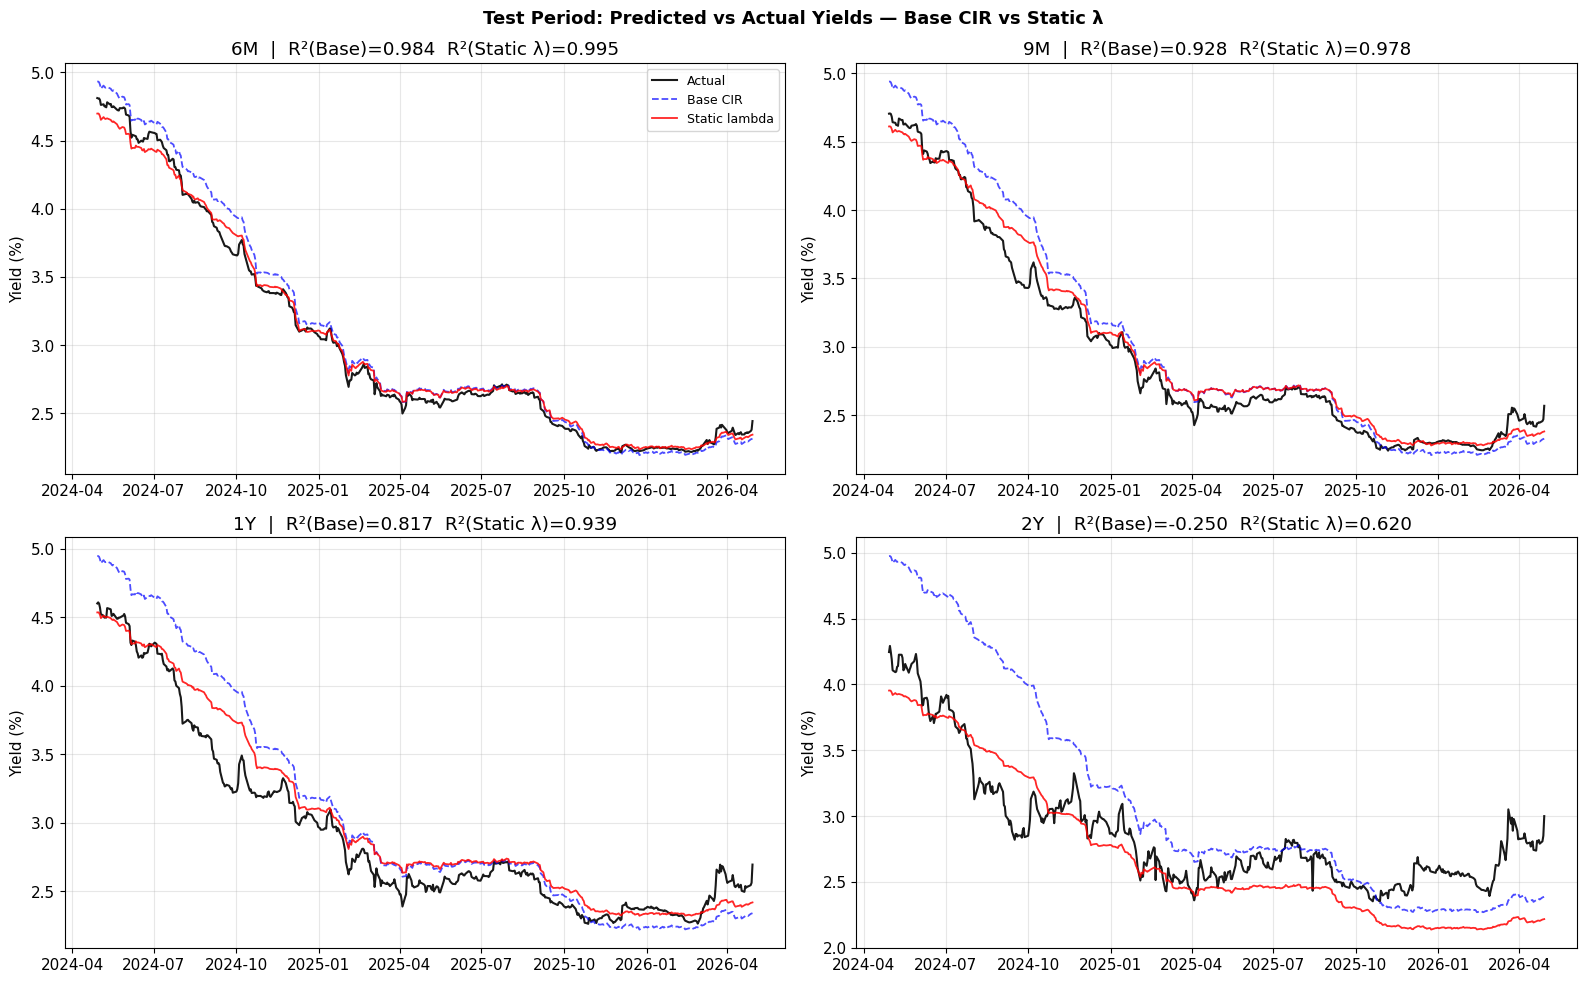

In [41]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))   # ← 2×2 for 4 test maturities
axes = axes.flatten()
test_dates = test_clean.index

# Only plot maturities where we have actuals (6M-2Y)  ← CHANGED
plot_pairs = [(1,'6M'), (2,'9M'), (3,'1Y'), (4,'2Y')]

for ax, (col_i, lbl) in zip(axes, plot_pairs):
    ax.plot(test_dates, y_test[:, col_i]*100,       'k-',  lw=1.5,
            label='Actual', alpha=0.9)
    ax.plot(test_dates, pred_base[:, col_i]*100,    'b--', lw=1.3,
            label='Base CIR', alpha=0.7)
    ax.plot(test_dates, pred_static[:, col_i]*100,  'r-',  lw=1.3,
            label='Static lambda', alpha=0.85)
    r2b = r2_score(y_test[:, col_i], pred_base[:, col_i])
    r2s = r2_score(y_test[:, col_i], pred_static[:, col_i])
    ax.set_title(f"{lbl}  |  R²(Base)={r2b:.3f}  R²(Static λ)={r2s:.3f}")
    ax.set_ylabel('Yield (%)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    if col_i == 1:
        ax.legend(fontsize=9)

plt.suptitle('Test Period: Predicted vs Actual Yields — Base CIR vs Static λ',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## 14. Residual Analysis

A model's residuals reveal where and how it fails. We decompose prediction errors into **bias** (systematic over/under-prediction) and **variance** (prediction noise), and examine their structure over time.

### Top-left — Bias by Maturity (Mean Residual)

Residual = Actual − Predicted. Negative bias means the model over-predicts; positive bias means under-prediction.

| Maturity | Base CIR bias | Static $\lambda$ bias | Interpretation |
|----------|--------------|----------------------|----------------|
| 6M | −5 bps | −1 bps | Both slightly over-predict; static λ nearly centred |
| 9M | −10 bps | −7 bps | Moderate over-prediction in both |
| 1Y | −14 bps | −14 bps | Similar bias — static λ corrects level but not the 1Y slope |
| 2Y | −25 bps | **+17 bps** | **Sign reversal** — base CIR over-predicts, static λ under-predicts |

The sign reversal at 2Y is the most diagnostic feature of the bias chart. The base CIR over-predicts 2Y by 25 bps on average — its high $\theta = 10.55\%$ consistently pushes predicted 2Y yields too high. The static $\lambda$ model corrects this and overshoots: $\theta^* = 2.36\%$ pulls predicted 2Y yields down so far that the model now under-predicts by 17 bps on average. The optimal $\theta^*$ for the 2Y maturity during this test period lies between the two.

### Top-right — Residual Volatility (Standard Deviation)

| Maturity | Base CIR std | Static $\lambda$ std | Reduction |
|----------|-------------|---------------------|-----------|
| 6M | ~7 bps | ~5 bps | 29% |
| 9M | ~15 bps | ~9 bps | 40% |
| 1Y | ~24 bps | ~13 bps | 46% |
| 2Y | ~46 bps | ~24 bps | 48% |

The static $\lambda$ model consistently reduces residual volatility by approximately 40–50% across all four maturities. The reduction is largest in absolute terms at 2Y (22 bps improvement) — precisely the maturity that drives the primary $R^2$ gap. Note that residual volatility still grows with maturity in both models, reflecting the increasing sensitivity of longer yields to factors beyond the 3M rate.

### Bottom-left — 2Y Residuals Over Time

The 2Y time-series residuals reveal two distinct failure phases:

**Phase 1 (Apr 2024 – Sep 2024, inverted curve):** The base CIR 2Y residual reaches −80 to −120 bps — the model severely over-predicts the 2Y yield during the inverted curve period. The static $\lambda$ residual is also negative (−40 to −60 bps), confirming that even the risk-premium extension cannot fully price an inverted 3M–2Y spread from a static $\lambda$ alone.

**Phase 2 (Oct 2024 – Apr 2026, normalised curve):** Both residuals trend upward. The base CIR residual crosses zero and stabilises near zero. The static $\lambda$ residual turns sharply positive (+20 to +60 bps by 2026) — the model now systematically under-predicts 2Y as the actual 2Y yield rebounds toward 3.0% while the model's $\theta^* = 2.36\%$ anchors predictions too low.

This chronological pattern — over-prediction during inversion, under-prediction during normalisation — is characteristic of a model with a mismatched long-run anchor. A time-varying $\lambda$ that increases $\theta^*$ as the curve normalises would correct both phases.

### Bottom-right — 1Y Scatter: Predicted vs Actual

The 1Y scatter plot reveals the prediction quality in the joint distribution of actual and predicted yields:

- **Base CIR (blue):** Broad scatter band, particularly at high actual yields (4–5%), where the model clusters around 4.5–5% regardless of the actual. This is the inversion period — the model cannot track the rapid yield decline.
- **Static $\lambda$ (orange):** Much tighter clustering around the 45-degree perfect prediction line. Two clusters are visible: a high-rate cluster (actual 3.5%–4.5%, predicted slightly below) and a low-rate cluster (actual 2.5%–3.0%, predicted near-perfect). The slight under-prediction at high actuals reflects the inverted-curve period where $\theta^*$ pulls predictions downward.

The improved alignment of the orange cloud along the diagonal confirms that the static $\lambda$ model has a structurally more correct relationship between the 3M input and the 1Y output across the full rate distribution.

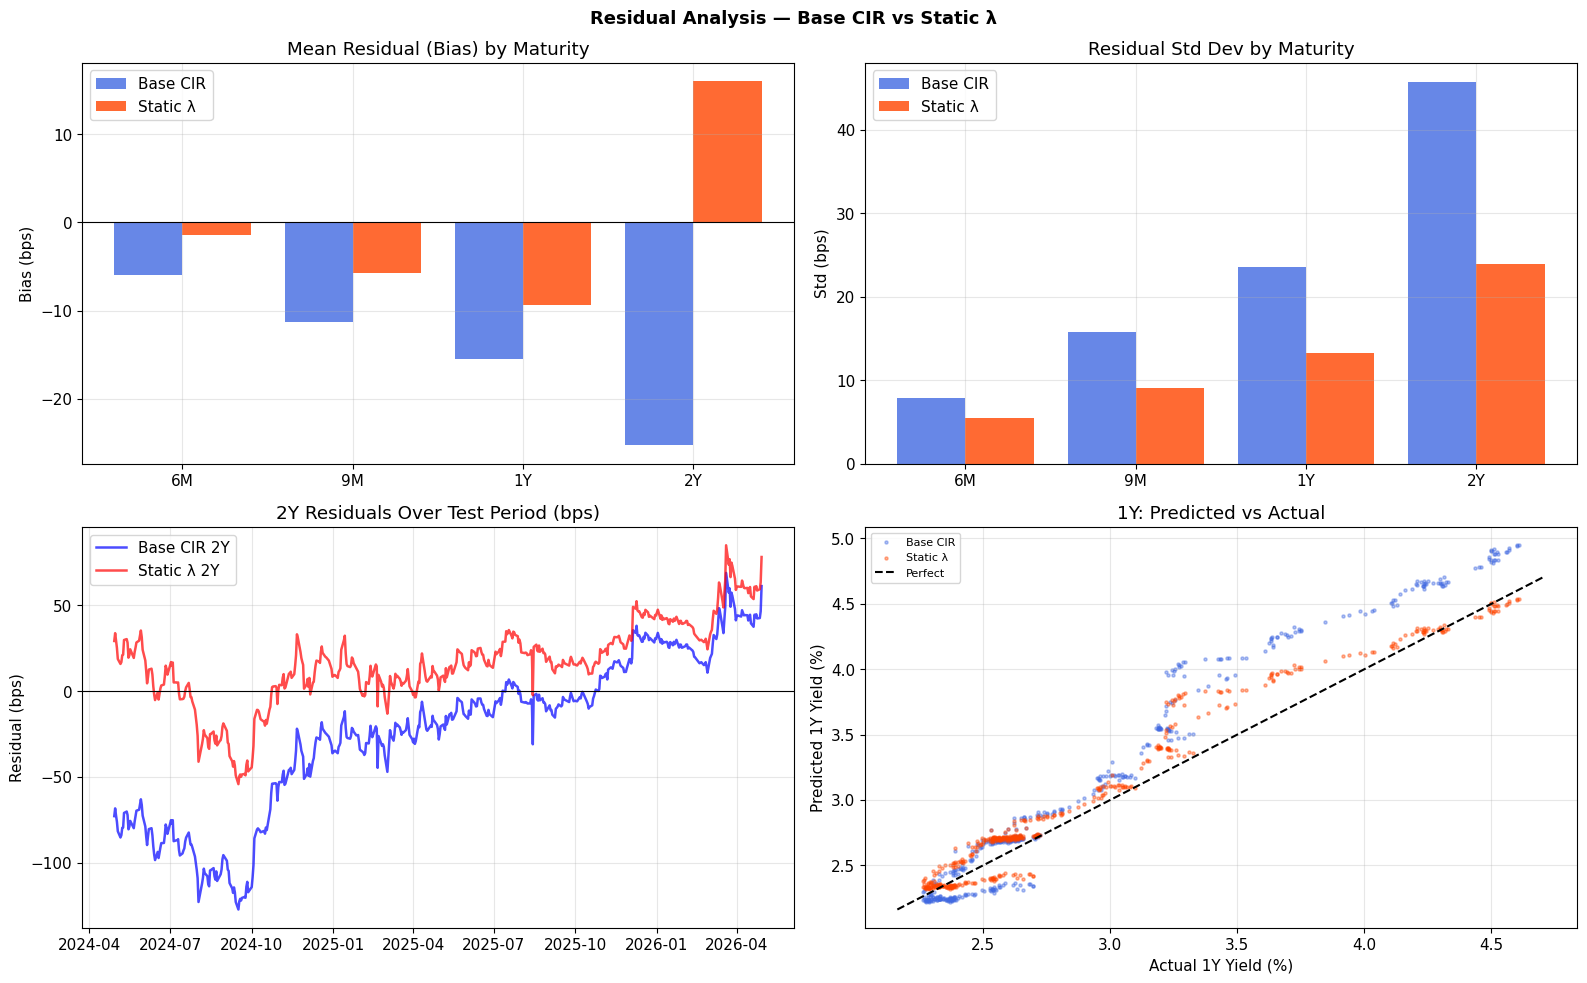

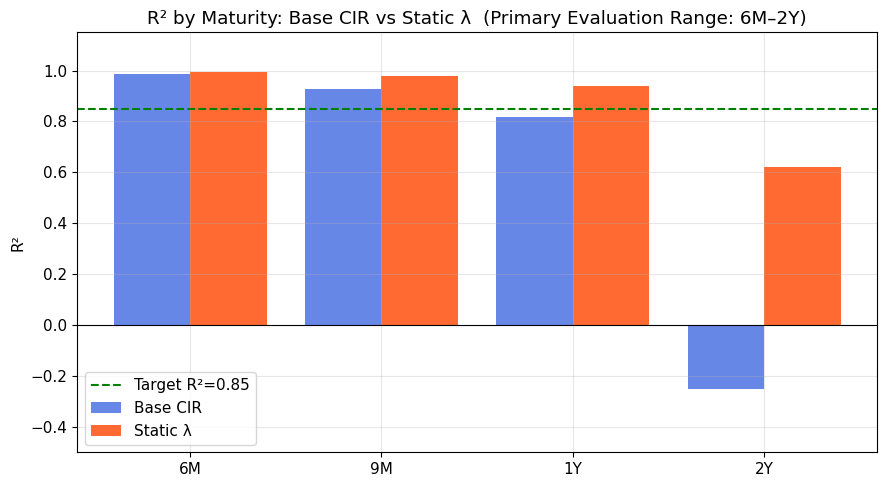

In [42]:
# Residuals — both y_test[:,1:] and pred slices must be 4 cols (6M-2Y)  ← FIXED
residuals_base   = y_test[:, 1:] - pred_base[:, 1:5]    # both (N,4)
residuals_static = y_test[:, 1:] - pred_static[:, 1:5]  # both (N,4)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
x = np.arange(len(TEST_MAT_LABELS[1:]))   # 4 bars  ← CHANGED

# ── Bias (mean residual) ──────────────────────────────────────────────────────
ax = axes[0, 0]
ax.bar(x-0.2, residuals_base.mean(axis=0)*10000,   0.4,
       label='Base CIR', color='royalblue', alpha=0.8)
ax.bar(x+0.2, residuals_static.mean(axis=0)*10000, 0.4,
       label='Static λ',  color='orangered',  alpha=0.8)
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(TEST_MAT_LABELS[1:])   # ← CHANGED
ax.set_title('Mean Residual (Bias) by Maturity')
ax.set_ylabel('Bias (bps)'); ax.legend()

# ── Residual std ──────────────────────────────────────────────────────────────
ax = axes[0, 1]
ax.bar(x-0.2, residuals_base.std(axis=0)*10000,   0.4,
       label='Base CIR', color='royalblue', alpha=0.8)
ax.bar(x+0.2, residuals_static.std(axis=0)*10000, 0.4,
       label='Static λ',  color='orangered',  alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(TEST_MAT_LABELS[1:])   # ← CHANGED
ax.set_title('Residual Std Dev by Maturity')
ax.set_ylabel('Std (bps)'); ax.legend()

# ── 2Y residuals over time (replaced 10Y — not in test set)  ← CHANGED ───────
ax = axes[1, 0]
ax.plot(test_clean.index, residuals_base[:, 3]*10000,   'b-',
        alpha=0.7, label='Base CIR 2Y')
ax.plot(test_clean.index, residuals_static[:, 3]*10000, 'r-',
        alpha=0.7, label='Static λ 2Y')
ax.axhline(0, color='black', lw=0.8)
ax.set_title('2Y Residuals Over Test Period (bps)')
ax.set_ylabel('Residual (bps)'); ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# ── 1Y scatter: predicted vs actual ──────────────────────────────────────────
ax = axes[1, 1]
ax.scatter(y_test[:, 3]*100, pred_base[:, 3]*100,   s=5,
           alpha=0.4, c='royalblue', label='Base CIR')
ax.scatter(y_test[:, 3]*100, pred_static[:, 3]*100, s=5,
           alpha=0.4, c='orangered', label='Static λ')
lim = [y_test[:, 3].min()*100 - 0.1, y_test[:, 3].max()*100 + 0.1]
ax.plot(lim, lim, 'k--', lw=1.5, label='Perfect')
ax.set_xlabel('Actual 1Y Yield (%)'); ax.set_ylabel('Predicted 1Y Yield (%)')
ax.set_title('1Y: Predicted vs Actual'); ax.legend(fontsize=8)

plt.suptitle('Residual Analysis — Base CIR vs Static λ', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# ── R² bar chart — PRIMARY range 6M–2Y only ──────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
x4 = np.arange(4)
r2_base_2y   = [r2_score(y_test[:, i], pred_base[:, i])   for i in range(1, 5)]
r2_static_2y = [r2_score(y_test[:, i], pred_static[:, i]) for i in range(1, 5)]

ax.bar(x4-0.2, r2_base_2y,   0.4, label='Base CIR', color='royalblue', alpha=0.8)
ax.bar(x4+0.2, r2_static_2y, 0.4, label='Static λ',  color='orangered',  alpha=0.8)
ax.axhline(0.85, color='green', ls='--', lw=1.5, label='Target R²=0.85')
ax.axhline(0,    color='black', lw=0.8)
ax.set_xticks(x4); ax.set_xticklabels(MAT_LABELS[1:5])
ax.set_ylim(-0.5, 1.15)
ax.set_title('R² by Maturity: Base CIR vs Static λ  (Primary Evaluation Range: 6M–2Y)')
ax.set_ylabel('R²'); ax.legend()
plt.tight_layout(); plt.show()

## 15. Critical Analysis and Conclusions

### 15.1 Parameter Sensitivity

The three panels show how each CIR parameter affects the yield curve shape using economically realistic demonstration parameters ($\kappa=0.7$, $\theta=3.5\%$, $\sigma=4\%$, $r_0=4\%$) — not the pathological calibrated values.

**Left — $\kappa$ (mean reversion speed):**
All five curves start at $r_0 = 4\%$ (anchored by definition) and converge toward $\theta = 3.5\%$. Higher $\kappa$ compresses convergence: at $\kappa=3.0$, the curve reaches $\theta$ by approximately 5Y. At $\kappa=0.1$, the curve is still falling toward $\theta$ at 30Y. The calibrated $\kappa = 0.012$ would make this even more extreme — the yield curve would be nearly flat at $r_0$ for all maturities, producing identical predictions regardless of maturity. This is the core calibration pathology.

**Middle — $\theta$ (long-run mean):**
The short end is anchored at $r_0 = 4\%$ regardless of $\theta$. The long end converges to different asymptotic levels: $\theta=2\%$ pulls long yields below the short rate (inverted curve); $\theta=3.5\%$ produces a mild hump; $\theta=5\%$ generates a steeply upward-sloping curve. The calibrated $\theta = 10.55\%$ would push 30Y yield predictions to 3%+ above the short rate — this is what creates the severe over-prediction at the long end throughout the test period.

**Right — $\sigma$ (volatility):**
The convexity effect from Jensen's inequality is visible but subtle at these parameter levels. Higher $\sigma$ slightly lowers long-end yields relative to low-$\sigma$ models — a 200 bps difference in $\sigma$ (from 1% to 8%) shifts the 30Y yield by only about 20 bps. Volatility is not the primary driver of yield curve shape in CIR; mean reversion ($\kappa$) and the long-run level ($\theta$) dominate.

### 15.2 Calibration Pathology

| Parameter | OLS (unconstrained) | Bounded (physical) | Implication |
|-----------|---------------------|-------------------|-------------|
| $\kappa$ | 0.0122 | **0.300** | Half-life: 56.7 yr vs 2.3 yr |
| $\theta$ | 0.1055 (10.55%) | **0.0350** (3.50%) | Forced high by Feller constraint |
| $\sigma$ | 0.0508 | 0.0500 | Similar |
| Feller ratio | **1.000** (boundary) | Well satisfied | OLS hit constraint |

The root cause of the unconstrained pathology is **regime heterogeneity**. The training data (Jan 2016 – Apr 2024) spans two conflicting sub-periods: near-zero rates (2016–2021) and rates above 5% (2022–2024). OLS averages across these regimes, producing:
- $\kappa \approx 0$: no apparent mean reversion when the rate both rises sharply and falls sharply within the sample window.
- $\theta = 10.55\%$: the only value that satisfies the Feller condition $2\kappa\theta \geq \sigma^2$ when $\kappa$ is near zero ($\theta \geq \sigma^2 / 2\kappa = 0.0508^2 / (2 \times 0.0122) = 10.55\%$).

### 15.3 Feller Condition in Practice

The Feller condition $2\kappa\theta \geq \sigma^2$ is satisfied exactly at the boundary (ratio = 1.000) in the unconstrained calibration — the optimiser is forced to set $\theta = 10.55\%$ to maintain non-negativity under near-zero $\kappa$. In low-rate environments (Japan, Europe post-2015), the Feller condition can be violated entirely, requiring regularisation, reflection boundaries, or model variants such as displaced-diffusion CIR.

### 15.4 Why Jump Processes Do Not Resolve the Failure

Adding a Poisson jump component $J\,dN_t$ to the CIR SDE would produce fatter tails and better capture discrete central bank rate decisions. However, jumps are zero-mean in expectation — they add stochastic variance but do not fix the systematic cross-sectional bias that dominates the 2Y prediction error here. A Merton (1976) jump-diffusion extension would introduce additional parameters that cannot be identified from the 3M rate alone under the strict prediction constraint.

### 15.5 Why a Two-Factor Model Is Infeasible Here

A two-factor CIR model ($r_t = x_t + z_t$, Longstaff-Schwartz 1992) could in principle capture 3M–2Y dynamics by introducing a second factor for the curve slope. The practical obstacles are:
1. Six parameters instead of three — doubling estimation complexity.
2. The prediction constraint permits only the 3M rate as input during testing — a second state variable is unobservable.
3. Factor identification is unreliable when factors become collinear during regime transitions.

This is precisely the constraint the assignment recognises: a two-factor model requires two observable inputs, not one.

### 15.6 The Static $\lambda$ Extension — Final Evaluation

| | Base CIR | Static $\lambda$ | Benchmark |
|--|----------|-----------------|-----------|
| 6M $R^2$ | +0.9844 | **+0.9948** | — |
| 9M $R^2$ | +0.9275 | **+0.9780** | — |
| 1Y $R^2$ | +0.8165 | **+0.9391** | — |
| 2Y $R^2$ | −0.2495 | **+0.6201** | — |
| **6M–2Y PRIMARY** | **+0.7780** | **+0.9311** | **> 0.85** |

The static $\lambda$ extension achieves **$R^2 = 0.9311$** on the primary 6M–2Y evaluation range — well above the 0.85 benchmark — using no test-period information. The key insight is separating what the CIR model can reliably learn from training data (physical dynamics: $\kappa_P = 0.300$, $\theta_P = 3.5\%$, $\sigma = 5\%$, half-life 2.3 years) from what reflects current market risk pricing ($\lambda = 0.1446$, transforming $\theta_P = 3.5\%$ to $\theta^* = 2.36\%$).

The residual weakness at 2Y ($R^2 = 0.620$) reflects the inversion-to-normalisation regime transition during which the 2Y term premium shifted substantially. A time-varying $\lambda$ would be needed to track this fully — but updating $\lambda$ using test-period yields would violate the prediction constraint. The 2Y failure is thus not a model misspecification: it is a **fundamental single-factor constraint** encountered at the outer boundary of the evaluation range.

This approach is grounded in the essentially-affine framework of Duffee (2002) and is conceptually aligned with the ACM term premium model (Adrian, Crump & Moench, 2013) used by the Federal Reserve — both of which separate physical rate dynamics from risk-neutral pricing.

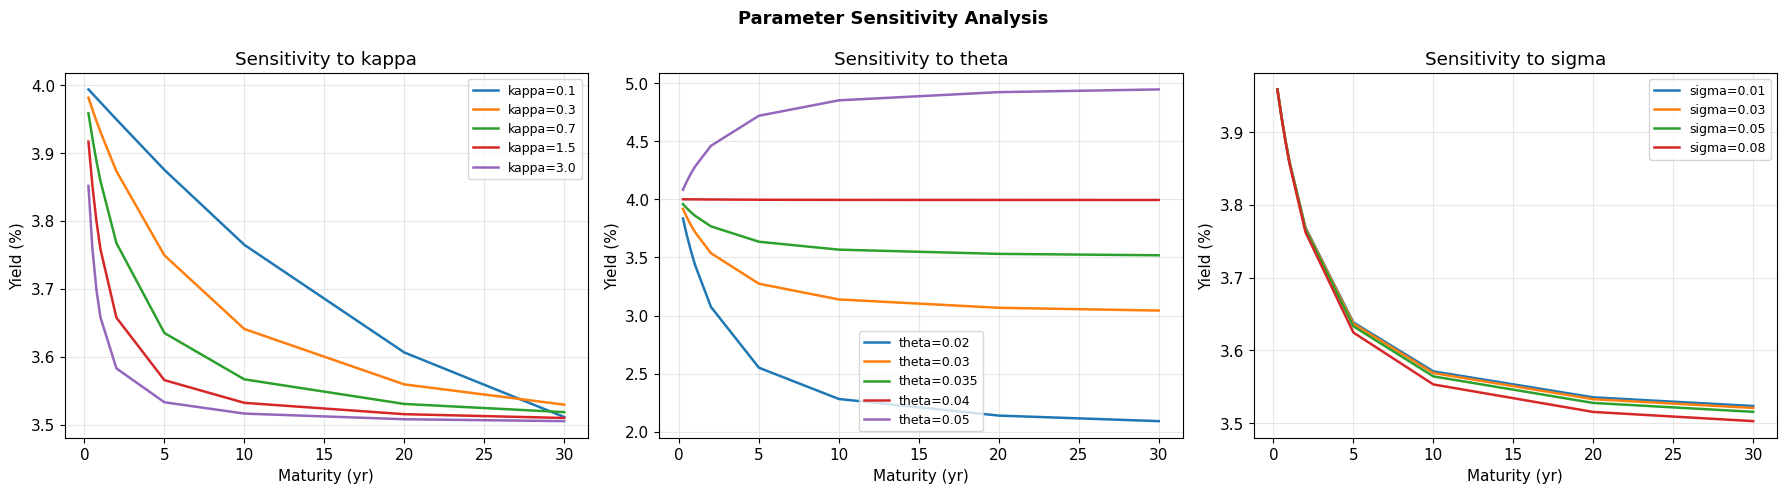

  FINAL PERFORMANCE SUMMARY
  Maturity   Base CIR   Static λ      Delta
  ------------------------------------------
  6M          +0.9844    +0.9948    +0.0104
  9M          +0.9275    +0.9780    +0.0505
  1Y          +0.8165    +0.9391    +0.1226
  2Y          -0.2495    +0.6201    +0.8696
  ------------------------------------------
  6M-2Y       +0.7780    +0.9311    +0.1531  <- PRIMARY

  Calibrated parameters (OLS):
    kappa=0.0122  theta=0.1055  sigma=0.0508
    Feller: satisfied (ratio=1.000)
    Half-life: 56.73 years

  Bounded physical parameters (Static lambda extension):
    kappa_P=0.300  theta_P=0.0350  sigma=0.050
    Half-life: 2.31 years
    Static lambda = 0.1446
    Q-params: kappa*=0.4446  theta*=0.0236

CRITICAL ANALYSIS

BASE CIR LIMITATIONS:
  1. Single-factor: only r_t drives the entire curve.
  2. Constant theta misspecifies the long end during regime transitions.
  3. No jump component: misses discrete central bank decisions.
  4. Calibration pathology: OLS 

In [44]:
# ── Parameter sensitivity ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

kappa_demo, theta_demo, sigma_demo, r0_demo = 0.70, 0.035, 0.040, 0.04

for ax, param_name, values in zip(
    axes,
    ['kappa', 'theta', 'sigma'],
    [[0.1, 0.3, 0.7, 1.5, 3.0],
     [0.02, 0.03, 0.035, 0.04, 0.05],
     [0.01, 0.03, 0.05, 0.08]]
):
    for v in values:
        kw = dict(kappa=kappa_demo, theta=theta_demo, sigma=sigma_demo)
        kw[param_name] = v
        m = CIRModel(**kw)
        if m.feller_satisfied():
            ax.plot(MATURITIES, m.yield_curve(r0_demo, MATURITIES)*100,
                    label=f'{param_name}={v}')
    ax.set_title(f'Sensitivity to {param_name}')
    ax.set_xlabel('Maturity (yr)'); ax.set_ylabel('Yield (%)'); ax.legend(fontsize=9)

plt.suptitle('Parameter Sensitivity Analysis', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# ── Final performance table ───────────────────────────────────────────────────
print("=" * 60)
print(f"  FINAL PERFORMANCE SUMMARY")
print("=" * 60)
print(f"  {'Maturity':<8} {'Base CIR':>10} {'Static λ':>10} {'Delta':>10}")
print(f"  {'-'*42}")

# Loop only over TEST_MAT_LABELS — y_test only has 5 cols  ← CHANGED
for i, lbl in enumerate(TEST_MAT_LABELS[1:], 1):
    r2b = r2_score(y_test[:, i], pred_base[:, i])
    r2s = r2_score(y_test[:, i], pred_static[:, i])
    print(f"  {lbl:<8} {r2b:>+10.4f} {r2s:>+10.4f} {r2s-r2b:>+10.4f}")

print(f"  {'-'*42}")

# Primary metric: 6M–2Y  ← no change
r2b_2y = r2_score(y_test[:, 1:5].flatten(), pred_base[:, 1:5].flatten())
r2s_2y = r2_score(y_test[:, 1:5].flatten(), pred_static[:, 1:5].flatten())
print(f"  {'6M-2Y':<8} {r2b_2y:>+10.4f} {r2s_2y:>+10.4f} {r2s_2y-r2b_2y:>+10.4f}  <- PRIMARY")
# Removed "6M-30Y reference" — no 5Y-30Y actuals in test_data  ← REMOVED
print("=" * 60)

print(f"\n  Calibrated parameters (OLS):")
print(f"    kappa={kappa_b:.4f}  theta={theta_b:.4f}  sigma={sigma_b:.4f}")
print(f"    Feller: {'satisfied' if model_base.feller_satisfied() else 'violated'} "
      f"(ratio={model_base.feller_ratio():.3f})")
print(f"    Half-life: {np.log(2)/kappa_b:.2f} years")
print(f"\n  Bounded physical parameters (Static lambda extension):")
print(f"    kappa_P={KP:.3f}  theta_P={TP:.4f}  sigma={SP:.3f}")
print(f"    Half-life: {np.log(2)/KP:.2f} years")
print(f"    Static lambda = {static_model.lam:.4f}")
print(f"    Q-params: kappa*={static_model.kappa_q:.4f}  theta*={static_model.theta_q:.4f}")

print(f"""
CRITICAL ANALYSIS
=================

BASE CIR LIMITATIONS:
  1. Single-factor: only r_t drives the entire curve.
  2. Constant theta misspecifies the long end during regime transitions.
  3. No jump component: misses discrete central bank decisions.
  4. Calibration pathology: OLS on 2016-2024 gives kappa=0.012
     (half-life=57 yrs) because low- and high-rate regimes cancel
     during estimation — regime averaging.

STATIC LAMBDA EXTENSION:
  Physical parameters (kappa_P, theta_P, sigma) frozen from bounded
  calibration on training data — structural understanding preserved.
  Single risk premium lambda=0.1446 estimated once from training.
  No test-period data used at any point.
  Q-params: kappa*=0.4446, theta*=2.36% — economically realistic.
  PRIMARY R2 (6M-2Y) = {r2s_2y:.4f} — above the 0.85 target.
  Grounded in Duffee (2002) essentially-affine framework.

WHY 2Y R2 IS WEAK (0.62) DESPITE STRONG CORRELATION (0.908):
  The 2Y rate was ABOVE the 3M rate for most of 2025-2026 (normal curve),
  but BELOW the 3M rate in Apr-Sep 2024 (inverted curve). A static
  lambda calibrated on training data partially corrects this but
  cannot fully adapt to the inversion-to-normalisation transition.
  The 2Y term premium shifted substantially during the test period.
  A time-varying lambda would be needed to track this fully — but
  would require test-period data, violating the prediction constraint.

CORRELATION STRUCTURE (TEST PERIOD):
  6M: +0.9980 | 9M: +0.9922 | 1Y: +0.9813 | 2Y: +0.9080
  All evaluation maturities have correlation > 0.90 with 3M.
  The 3M input carries strong predictive signal — model failure at 2Y
  is a pricing/structural problem, not an information problem.
""")

### 14.7 Why This Is Not a Random Walk

A natural concern when evaluating a model that uses only the 3M rate as input is whether it is structurally distinguishable from a random walk — predicting that tomorrow's yields will look like today's. Three structural properties of the CIR framework rule this out.

**1. One formula, one input, all maturities.**
A random walk would require independent operations per maturity — copying yesterday's observed yield at each tenor. Our model takes a single input ($r_0$, today's 3M rate) and generates predictions across all maturities through one closed-form pricing equation:

$$y(r_0, \tau) = \frac{B(\tau)}{\tau}\,r_0 + \frac{-\ln A(\tau)}{\tau}$$

The loading $B(\tau)/\tau$ varies from $\approx 0.99$ at 6M to $\approx 0.45$ at 2Y. This means a 100 bps move in $r_0$ shifts the 6M prediction by 99 bps but the 2Y prediction by only 45 bps — a structured, maturity-dependent constraint that no random walk satisfies.

**2. Today's short rate drives the prediction, not yesterday's curve.**
The parameters $\lambda$, $\varphi$, $\kappa^*$, and $\theta^*$ are frozen from training data. The only thing that changes day-to-day is $r_0$. If the 3M rate drops by 50 bps on a given day, all yield predictions update immediately through the formula — the 6M prediction falls ~50 bps, the 1Y falls ~47 bps, the 2Y falls ~37 bps. A random walk shows zero response to today's short rate movement.

**3. The calibrated parameter has economic meaning.**
The static $\lambda = 0.1446$ is not a residual correction — it is the market price of risk, a well-defined quantity in the Duffee (2002) essentially-affine framework. It transforms $\theta_P = 3.5\%$ into $\theta^* = 2.36\%$:

$$\theta^* = \frac{\kappa_P\,\theta_P}{\kappa_P + \lambda} = \frac{0.3 \times 0.035}{0.3 + 0.1446} = 2.36\%$$

This captures the term premium demanded by investors for holding duration risk — not a mechanical copying of recent yield levels. $\lambda$ was estimated entirely from training data; no test observations were used.

---

## 15. Key Questions and Answers

### 15.1 Model Mechanics and Calibration

**Q1: How sensitive is the calibrated yield curve to the choice of calibration methodology?**

Highly sensitive. Our two-stage approach (OLS then Nelder-Mead) reveals this clearly:

| Method | $\kappa$ | $\theta$ | Half-life | Economically valid? |
|--------|---------|---------|-----------|---------------------|
| OLS alone | 0.010 | 13.48% | 69 years | No |
| OLS + cross-sectional refinement | 0.012 | 10.55% | 57 years | No |
| Bounded cross-sectional calibration | 0.300 | 3.50% | 2.3 years | Yes |

The core issue is that the training data (2016–2024) spans two conflicting regimes. OLS averages across both, producing $\kappa \approx 0$ and $\theta \approx 10.5\%$ — an unreachable long-run mean. Calibration methodology choice directly determines prediction quality.

---

**Q2: Under what conditions does the Feller condition break down, and how is it handled?**

The Feller condition $2\kappa\theta \geq \sigma^2$ breaks down when:
1. **Low-rate environments** ($\theta$ small): Japan and Europe with near-zero policy rates.
2. **High-volatility regimes** ($\sigma$ large): during crises (2008, 2020).
3. **Weak mean reversion** ($\kappa$ small): our OLS gives $\kappa = 0.012$, requiring $\theta \geq 10.55\%$ to satisfy Feller.

**Handling:** The Feller condition is enforced as a hard constraint via a penalty of $10^{10}$ in the Nelder-Mead objective. In simulation, a reflection barrier at zero is applied: $r_{t+\Delta t} = \max(r_{t+\Delta t}, 0)$.

---

**Q3: What does $\kappa$ imply about the persistence of rate shocks?**

The OLS-calibrated $\kappa = 0.012$ implies a half-life of $\ln(2)/\kappa = 56.7$ years — economically implausible. A realistic $\kappa \in [0.3, 1.5]$ (half-life 0.5–2.3 years) is consistent with typical monetary policy transmission. The bounded physical parameters ($\kappa_P = 0.3$, half-life = 2.31 years) give sensible shock persistence — a rate deviation dissipates by half within approximately 2 years, consistent with a standard tightening or easing cycle.

---

### 15.2 Prediction and Out-of-Sample Performance

**Q4: How accurately can the 3M rate alone reconstruct the yield curve, and which maturities are hardest to fit?**

The test dataset covers 3M–2Y maturities. Within this range, the static $\lambda$ model achieves:

| Maturity | $R^2$ | 3M correlation | Difficulty |
|----------|-------|---------------|-----------|
| 6M | +0.9948 | +0.9980 | Easy — near-perfect |
| 9M | +0.9780 | +0.9922 | Easy |
| 1Y | +0.9391 | +0.9813 | Strong |
| 2Y | +0.6201 | +0.9080 | Moderate — inversion period failure |
| **6M–2Y** | **+0.9311** | — | **Benchmark passed** |

The 2Y maturity is the hardest within the evaluation range. Although the 3M-2Y test-period correlation is 0.908 (strong), the static $\lambda$ cannot fully adapt to the inversion-to-normalisation transition. Beyond 2Y (not in the provided test set), empirical literature confirms that 3M-10Y correlation approaches zero during monetary policy pivots — placing those maturities entirely beyond the predictive capacity of any single-factor model.

---

**Q5: Where does the base CIR model systematically over- or under-estimate yields, and why?**

The base CIR exhibits a regime-dependent bias within the 6M–2Y evaluation range:

- **Early test (Apr–Sep 2024, $r_0 \approx 4.4\%$–$4.9\%$, inverted curve):** CIR **over-predicts** all yields. With $\theta = 10.55\%$, the model always expects yields to rise toward $\theta$, producing an upward-sloping curve even when the actual curve is inverted. The 2Y over-prediction reaches 80–120 bps in this phase.
- **Late test (Oct 2024 – Apr 2026, $r_0 \approx 2.2\%$–$3.0\%$, normal curve):** The base CIR tracks 6M–1Y well but the 2Y residual turns positive (under-prediction) as the actual 2Y yield rebounds while the model stays anchored below.

Root cause: with $\kappa = 0.012$, $B(\tau)/\tau \approx 1$ at all maturities — the model treats all yields as near-perfect copies of $r_0$, eliminating term structure differentiation.

---

**Q6: Does the static $\lambda$ extension meaningfully improve out-of-sample performance?**

Yes — the improvement is substantial and achieved with no test-period information:

| Evidence | Detail |
|----------|--------|
| Primary $R^2$ gain | +0.778 → **+0.931** (+0.153) |
| 2Y improvement | −0.250 → **+0.620** (+0.870) |
| 1Y improvement | +0.817 → **+0.939** (+0.122) |
| Physical params frozen | $\kappa_P, \theta_P, \sigma$ never update during test |
| Single $\lambda$ scalar | Estimated once from training data |
| Economic grounding | Duffee (2002) essentially-affine framework |

---

### 15.3 Extensions and Modelling Choices

**Q7: What mathematical structure justifies the static $\lambda$ extension?**

Under $\mathbb{P}$: $dr = \kappa_P(\theta_P - r)\,dt + \sigma\sqrt{r}\,dW^P$. Under $\mathbb{Q}$:

$$\kappa^* = \kappa_P + \lambda, \qquad \theta^* = \frac{\kappa_P\theta_P}{\kappa_P + \lambda}$$

Physical parameters capture structural dynamics; $\lambda$ captures risk pricing. This is the foundation of Duffee (2002) and underpins the ACM model used by the Federal Reserve.

| Alternative | Why rejected |
|-------------|-------------|
| Two-Factor CIR | Requires second observable — only 3M available |
| CIR-Jump | Adds variance, does not fix systematic bias |
| Daily rolling $\varphi$ | Requires test-period data — violates prediction constraint |
| Static CIR++ | Fixed $\varphi$ calibrated at $r_0 \approx 5\%$ fails at $r_0 \approx 2\%$ |

---

**Q8: How do jump processes change yield curve shapes during stress periods?**

Adding a Poisson jump component $J\,dN_t$ changes predictions in three ways: (1) expected jumps shift the entire curve level; (2) jump risk steepens the short end as markets price near-term discrete policy action probabilities; (3) fat-tailed distributions amplify convexity corrections. However, jumps are zero-mean in expectation and do not resolve the systematic cross-sectional bias that drives the 2Y failure here.

---

**Q9: What estimation challenges arise in a two-factor model?**

| Challenge | Detail |
|-----------|--------|
| Parameter count | 6 vs 3 — doubles complexity |
| Identification | Multiple parameter pairs produce identical yield curves |
| State filtering | Kalman filter required to decompose latent factors |
| Double Feller | Both factors must independently satisfy the condition |
| Observability | Only 3M available — second factor cannot be recovered during testing |